In [133]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Data Load

In [134]:
rnadist100 = "./BRONZE/long_run_filter100/rnadist/dist_100/"
FIGURE_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/figures/"
# familias
fams = ['23s', 'telomerase', '16s', '5s', 'grp1', 'srp', 'RNaseP', 'tmRNA', 'tRNA']

def read_dfs(BASE_PATH, output_base=None, label="rnadist100"):
    epochs = [n*5 for n in range(1,11)]
    dfs = { f: [] for f in fams }

    for f in fams:
        for i, ep in enumerate(epochs):
            path = os.path.join(BASE_PATH, f"{ep}_epoch", f)
            
            train = pd.read_csv(os.path.join(path, "train_log.csv"))
            if i > 0:
                train["epoch"] += epochs[i-1]
            test = pd.read_csv(os.path.join(path, "test.csv"))

            # insertar métricas de test en la última fila de train
            train.loc[train.index[-1], "f1"] = test["f1"].values[0]
            train.loc[train.index[-1], "f1_post"] = test["f1_post"].values[0]
            dfs[f].append(train)

        dfs[f] = pd.concat(dfs[f], ignore_index=True)

        # guardar si hay carpeta de salida
        if output_base is not None:
            out_dir = os.path.join(output_base, label, f)
            os.makedirs(out_dir, exist_ok=True)
            out_file = os.path.join(out_dir, "metrics_table.csv")
            dfs[f].to_csv(out_file, index=False)
            # print(f"Guardado: {out_file}")

    return dfs


# ejemplo de uso
dfs = read_dfs(rnadist100)


In [135]:
dfs["23s"].shape

(50, 8)

In [136]:
paths = {
    "rnadist400": "./BRONZE/long_run_filter100/rnadist/dist_400/",
    "rnadist200": "./BRONZE/long_run_filter100/rnadist/dist_200/",
    "rnadist100": "./BRONZE/long_run_filter100/rnadist/dist_100/",
    "hc400": "./BRONZE/long_run_filter100/herarchical_cluster/dist_400/",
    "hc200": "./BRONZE/long_run_filter100/herarchical_cluster/dist_200/",
    "hc100": "./BRONZE/long_run_filter100/herarchical_cluster/dist_100/",
    "samples400": "./BRONZE/long_run_filter100/samples/dist_400/",
    "samples200": "./BRONZE/long_run_filter100/samples/dist_200/",
    "samples100": "./BRONZE/long_run_filter100/samples/dist_100/",
    "famfold": "./BRONZE/long_run_filter100/famfold/"
}

# carpeta de salida base
BRONZE_OUTPUT = "./BRONZE/long_run_filter100/tables50e/"

for label, path in paths.items():
    dfs = read_dfs(path, BRONZE_OUTPUT, label=label)


# primer analisis

/tmp/ipykernel_2979725/3730152107.py:30: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


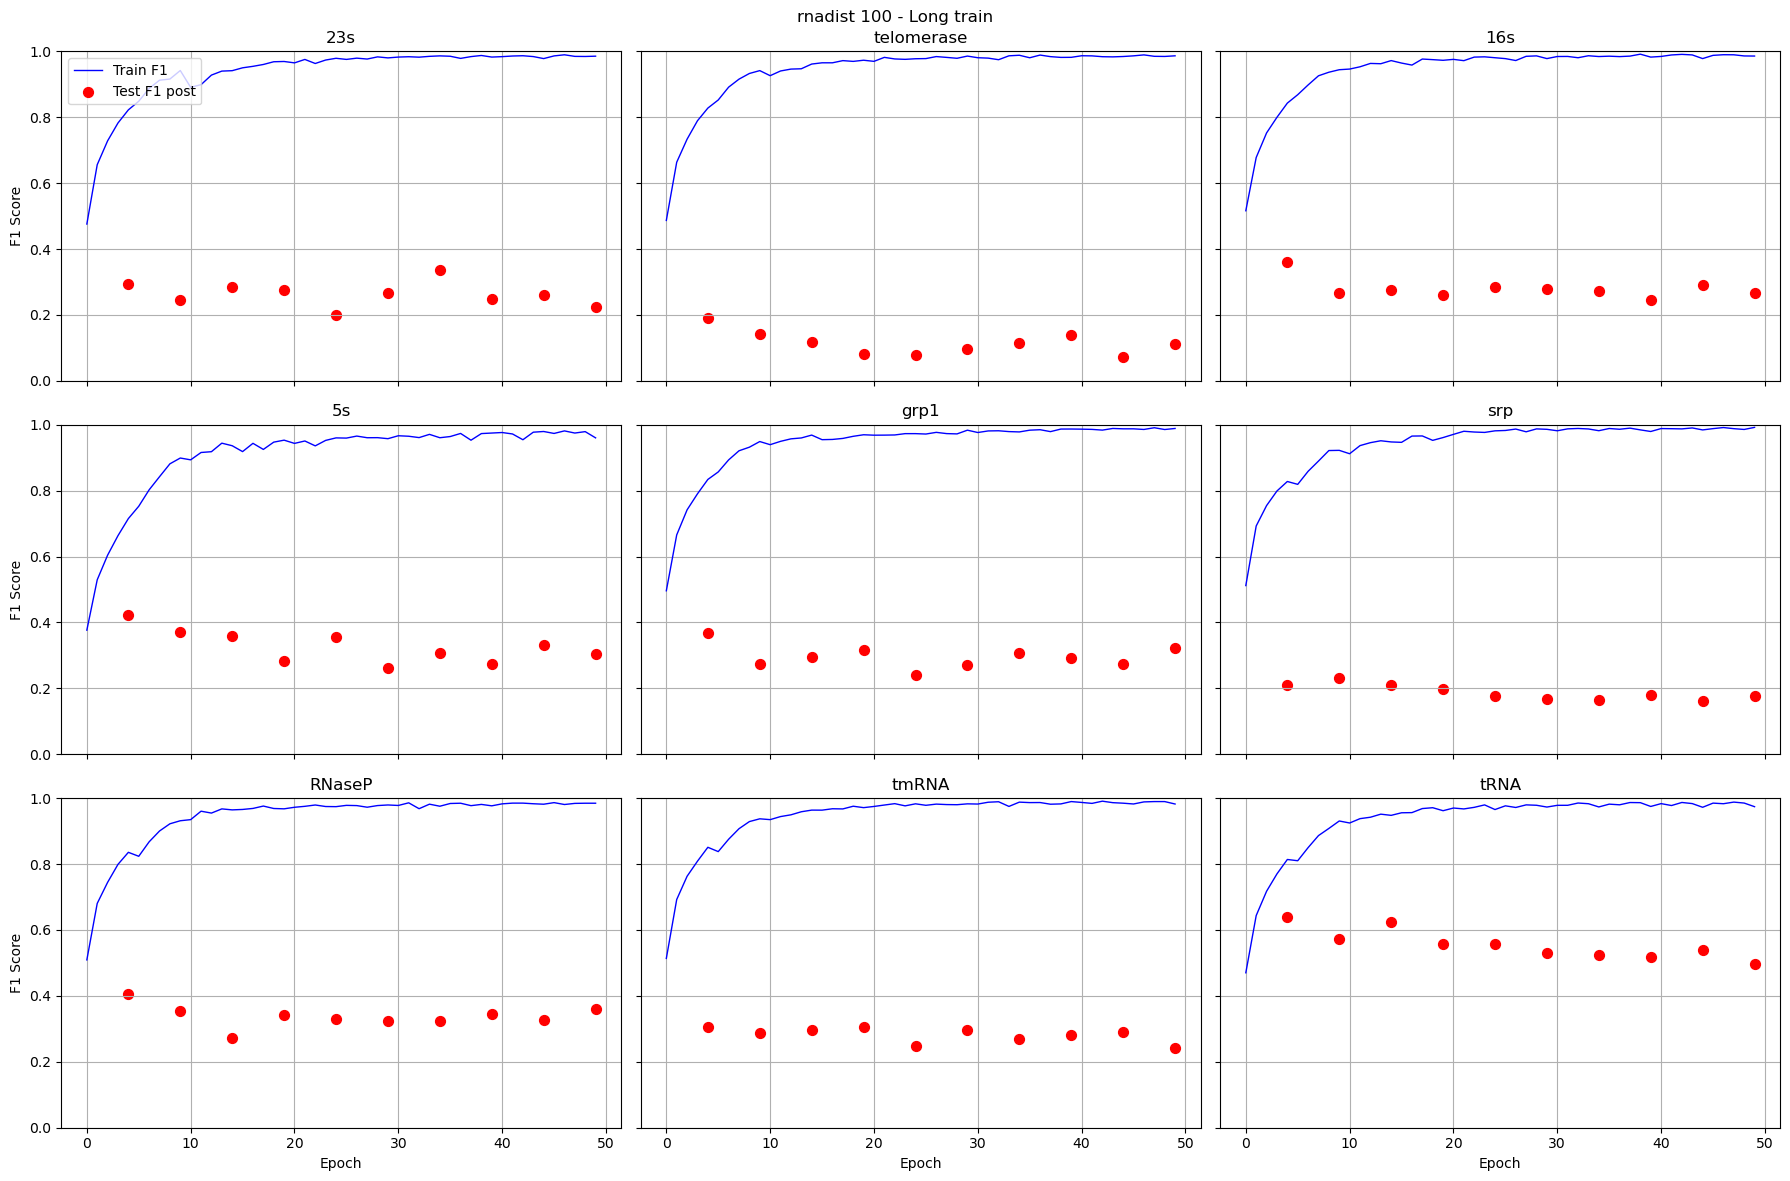

In [137]:
n_fams = len(fams)
cols = 3  # número de columnas en la figura
rows = (n_fams + cols - 1) // cols  # calcular filas necesarias

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), constrained_layout=True, sharex=True, sharey=True)
axes = axes.flatten()  # para indexar fácilmente

for ax, f in zip(axes, fams):
    df = dfs[f]
    ax.plot(df['epoch'], df['train_f1'], label='Train F1', color='blue', linewidth=1)
    
    # Test F1
    test_rows = df['f1_post'].notna()
    ax.scatter(df.loc[test_rows, 'epoch'], df.loc[test_rows, 'f1_post'],
               color='red', s=50, label='Test F1 post')
     
    ax.set_title(f'{f}', fontsize=12)
    ax.set_ylim(0, 1)  # uniforme para todas
    ax.grid(True)
for n in [6,7,8]:    
    axes[n].set_xlabel('Epoch')
for n in [0,3,6]:
    axes[n].set_ylabel('F1 Score')
axes[0].legend(loc="upper left")

# Si hay ejes sobrantes (más subplots que familias), los ocultamos
for ax in axes[n_fams:]:
    ax.set_visible(False)
fig.suptitle("rnadist 100 - Long train")
fig.tight_layout()
plt.show()


In [138]:
base = 557+1283+35+462+454+74+15+918+66

n=400
print(base)
for n in [100,200,400]:
    d= n+n+35+n+n+74+15+n+66
    print(d, round(d/base, 3))

3864
690 0.179
1190 0.308
2190 0.567


/tmp/ipykernel_2979725/1828078995.py:45: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


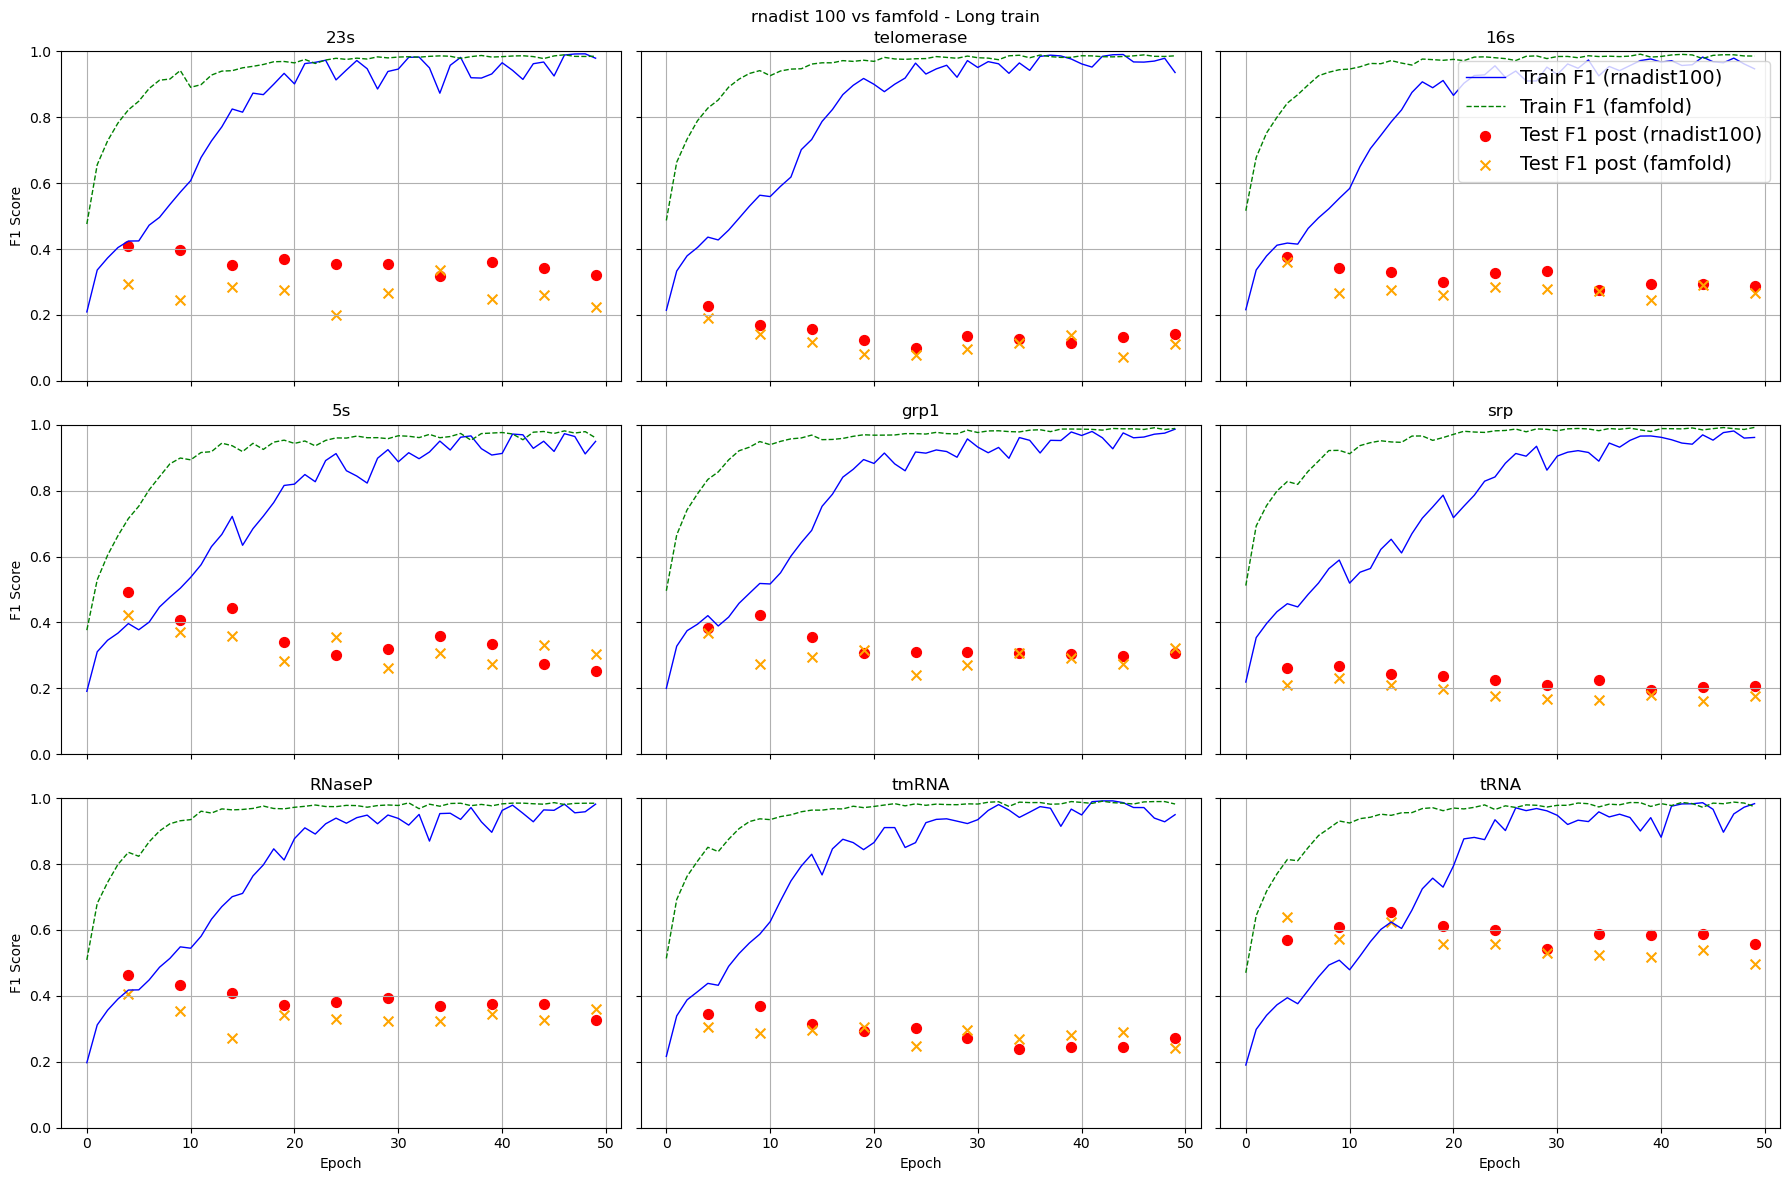

In [139]:
# leer ambos sets
dfs1 = read_dfs(paths["rnadist100"])
dfs2 = read_dfs(paths["famfold"])

n_fams = len(fams)
cols = 3
rows = (n_fams + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), constrained_layout=True, sharex=True, sharey=True)
axes = axes.flatten()

for ax, f in zip(axes, fams):
    df1 = dfs1[f]
    df2 = dfs2[f]

    # Train F1
    ax.plot(df1['epoch'], df1['train_f1'], label='Train F1 (rnadist100)', color='blue', linewidth=1)
    ax.plot(df2['epoch'], df2['train_f1'], label='Train F1 (famfold)',    color='green', linewidth=1, linestyle='--')

    # Test F1 post
    test_rows1 = df1['f1_post'].notna()
    test_rows2 = df2['f1_post'].notna()
    ax.scatter(df1.loc[test_rows1, 'epoch'], df1.loc[test_rows1, 'f1_post'],
               color='red', s=50, label='Test F1 post (rnadist100)')
    ax.scatter(df2.loc[test_rows2, 'epoch'], df2.loc[test_rows2, 'f1_post'],
               color='orange', s=50, marker='x', label='Test F1 post (famfold)')

    ax.set_title(f'{f}', fontsize=12)
    ax.set_ylim(0, 1)
    ax.grid(True)

for n in [6,7,8]:
    axes[n].set_xlabel('Epoch')
for n in [0,3,6]:
    axes[n].set_ylabel('F1 Score')

# legend solo en el primero
axes[2].legend(loc="upper right", fontsize=14)

# ocultar sobrantes
for ax in axes[n_fams:]:
    ax.set_visible(False)

fig.suptitle("rnadist 100 vs famfold - Long train")
fig.tight_layout()
plt.show()


/tmp/ipykernel_2979725/2197607880.py:48: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


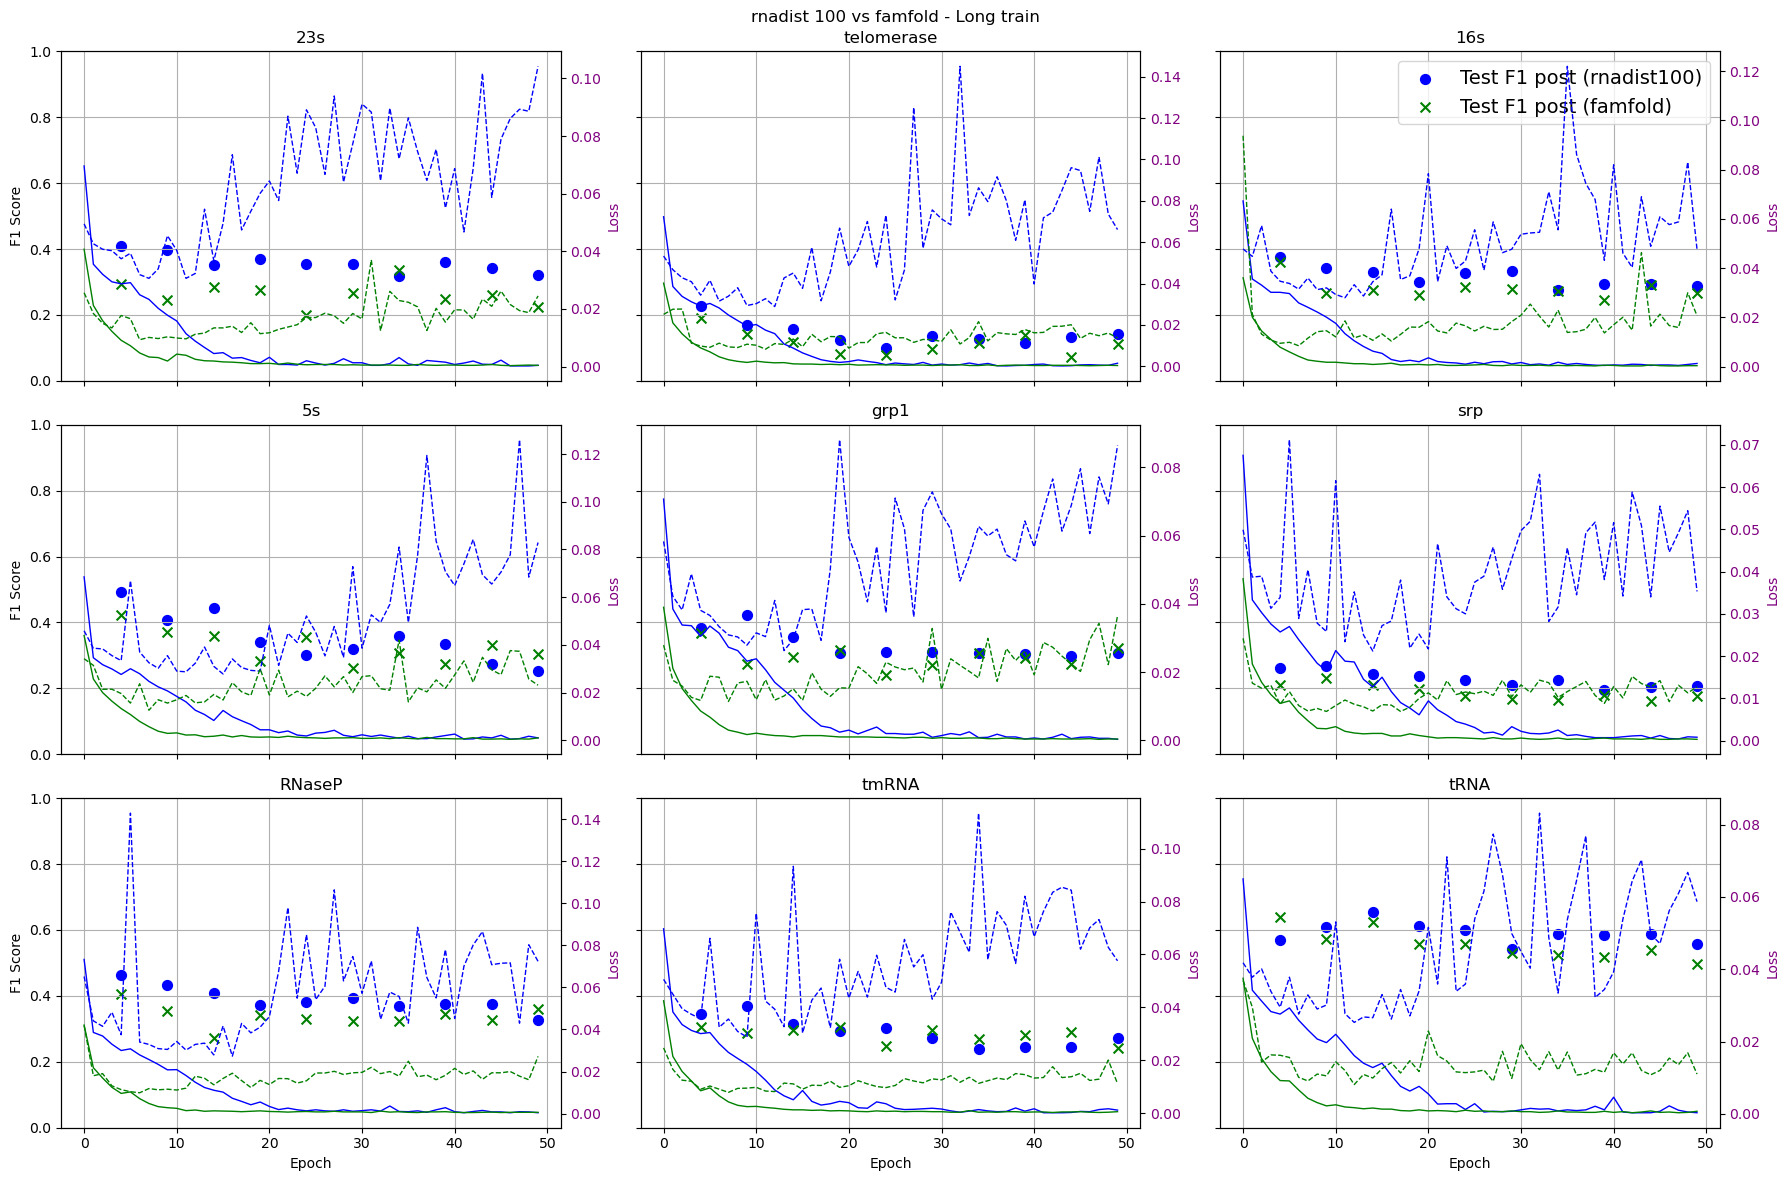

In [140]:
# leer ambos sets
dfs1 = read_dfs(paths["rnadist100"])
dfs2 = read_dfs(paths["famfold"])

n_fams = len(fams)
cols = 3
rows = (n_fams + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), constrained_layout=True, sharex=True, sharey=True)
axes = axes.flatten()

for ax, f in zip(axes, fams):
    df1 = dfs1[f]
    df2 = dfs2[f]


    # Test F1 post
    test_rows1 = df1['f1_post'].notna()
    test_rows2 = df2['f1_post'].notna()
    ax.scatter(df1.loc[test_rows1, 'epoch'], df1.loc[test_rows1, 'f1_post'],
               color='blue', s=50, label='Test F1 post (rnadist100)')
    ax.scatter(df2.loc[test_rows2, 'epoch'], df2.loc[test_rows2, 'f1_post'],
               color='green', s=50, marker='x', label='Test F1 post (famfold)')

    ax.set_title(f'{f}', fontsize=12)
    ax.set_ylim(0, 1)
    ax.grid(True)

    ax2 = ax.twinx()
    ax2.set_ylabel('Loss', color='purple')
    ax2.tick_params(axis='y', labelcolor='purple')
    # Train F1
    ax2.plot(df1['epoch'], df1['train_loss'], label='Train F1 (rnadist100)', color='blue', linewidth=1)
    ax2.plot(df1['epoch'], df1['valid_loss'], label='Train F1 (rnadist100)', color='blue', linewidth=1, linestyle='--')
    ax2.plot(df2['epoch'], df2['train_loss'], label='Train F1 (famfold)',    color='green', linewidth=1)
    ax2.plot(df2['epoch'], df2['valid_loss'], label='Train F1 (famfold)',    color='green', linewidth=1, linestyle='--')
     
for n in [6,7,8]:
    axes[n].set_xlabel('Epoch')
for n in [0,3,6]:
    axes[n].set_ylabel('F1 Score')

# legend solo en el primero
axes[2].legend(loc="upper right", fontsize=14)
 

fig.suptitle("rnadist 100 vs famfold - Long train")
fig.tight_layout()
plt.show()


In [141]:

def filter_dfs(dfs, max_epoch=50):
    out = {}
    for fam, df in dfs.items():
        # por si 'epoch' viene como string en algún caso
        df2 = df.copy()
        df2['epoch'] = pd.to_numeric(df2['epoch'], errors='coerce')
        out[fam] = df2.loc[df2['epoch'] <= max_epoch].copy()
    return out

# leer ambos sets
dfs_all = {k: read_dfs(v) for k, v in paths.items()}

dfs1 = dfs_all["famfold"]
dfs2 = dfs_all["rnadist100"]
dfs3 = dfs_all["rnadist200"]
dfs4 = dfs_all["rnadist400"]
# dfs1_ = filter_dfs(dfs1, max_epoch=50)
# dfs2_ = filter_dfs(dfs2, max_epoch=50)


In [142]:
dfs4['23s']

,epoch,train_f1,train_loss,valid_f1,valid_f1_post,valid_loss,f1,f1_post
0,0,0.3685,0.0460,0.4758,0.4809,0.0482,NaN,NaN
1,1,0.5027,0.0275,0.5245,0.6130,0.0271,NaN,NaN
2,2,0.5621,0.0229,0.6005,0.6564,0.0246,NaN,NaN
3,3,0.6061,0.0198,0.4755,0.6389,0.0297,NaN,NaN
4,4,0.6535,0.0163,0.6871,0.7367,0.0194,0.421,0.432
5,5,0.6842,0.0144,0.6434,0.6469,0.0412,NaN,NaN
6,6,0.7297,0.0115,0.6849,0.7615,0.0172,NaN,NaN
7,7,0.7852,0.0081,0.7401,0.7882,0.0174,NaN,NaN
8,8,0.8221,0.0063,0.5492,0.7218,0.0189,NaN,NaN
9,9,0.8641,0.0040,0.7737,0.7816,0.0273,0.270,0.273


# setup plots

In [143]:
import matplotlib.pyplot as plt

def smooth_curve(y, window=5):
    return y.rolling(window=window, center=True, min_periods=1).mean()

def plot_f1_across_datasets(datasets, dataset_names, fams, cols=3, figsize=(6, 4), dist_plot=False):
    """
    Grafica comparaciones de F1 (train y test) entre múltiples datasets.

    Parámetros
    ----------
    datasets : list
        Lista de diccionarios {fam_name: DataFrame}, por ejemplo [dfs1, dfs2, dfs3].
    dataset_names : list
        Lista con nombres descriptivos (mismo orden que datasets), por ejemplo ["rnadist100", "famfold"].
    fams : list
        Lista de nombres de familias a graficar (claves comunes a todos los datasets).
    cols : int, opcional
        Cantidad de columnas en la grilla de plots.
    figsize : tuple, opcional
        Tamaño base (ancho, alto) de cada subplot en pulgadas.

    Ejemplo
    --------
    dfs1 = read_dfs(rnadist100)
    dfs2 = read_dfs(famfold)
    plot_f1_across_datasets([dfs1, dfs2], ["rnadist100", "famfold"], fams)
    """
    
    n_fams = len(fams)
    rows = (n_fams + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0]*cols, figsize[1]*rows),
                             constrained_layout=True, sharex=True, sharey=True)
    axes = axes.flatten()

    # paleta consistente
    if dist_plot:
        base_colors = ['gray', 'brown', 'blue', "#42f084"]
    else:
        base_colors = ['gray', 'green', 'purple', 'orange', 'brown', 'blue']

    for ax, fam in zip(axes, fams):
        for i, (dfs, name) in enumerate(zip(datasets, dataset_names)):
            df = dfs[fam]

            color = base_colors[i % len(base_colors)] 

            # Train F1
            ax.plot(df['epoch'], df['train_f1'], label=f'F1 ({name})',
                    color=color, linewidth=1, )

            # Test F1 post
            test_rows = df['f1_post'].notna()
            ax.scatter(df.loc[test_rows, 'epoch'], df.loc[test_rows, 'f1_post'],
                       color=color, s=50, marker='o' if i == 0 else 'x',
                       label=None)

        ax.set_title(f'{fam}', fontsize=12)
        ax.set_ylim(0, 1)
        ax.set_xlim(0, 25)
        ax.grid(True)

    # Ejes
    for n in range(0, len(axes), cols):
        axes[n].set_ylabel('F1 Score')
    for n in range(len(axes) - cols, len(axes)):
        axes[n].set_xlabel('Epoch')

    # Leyenda solo en el último eje visible
    axes[2].legend(loc="upper right", fontsize=10)

    # Ocultar sobrantes
    for ax in axes[n_fams:]:
        ax.set_visible(False)

    fig.suptitle("Comparación de F1 entre datasets", fontsize=16)
    fig.tight_layout()
    plt.show()


In [144]:
def plot_valid_f1_across_datasets(datasets, dataset_names, fams, cols=3, figsize=(6, 4), dist_plot=False, save=False):
    """
    Grafica comparaciones de F1 (train y test) entre múltiples datasets.

    Parámetros
    ----------
    datasets : list
        Lista de diccionarios {fam_name: DataFrame}, por ejemplo [dfs1, dfs2, dfs3].
    dataset_names : list
        Lista con nombres descriptivos (mismo orden que datasets), por ejemplo ["rnadist100", "famfold"].
    fams : list
        Lista de nombres de familias a graficar (claves comunes a todos los datasets).
    cols : int, opcional
        Cantidad de columnas en la grilla de plots.
    figsize : tuple, opcional
        Tamaño base (ancho, alto) de cada subplot en pulgadas.

    Ejemplo
    --------
    dfs1 = read_dfs(rnadist100)
    dfs2 = read_dfs(famfold)
    plot_f1_across_datasets([dfs1, dfs2], ["rnadist100", "famfold"], fams)
    """
    
    n_fams = len(fams)
    rows = (n_fams + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0]*cols, figsize[1]*rows),
                             constrained_layout=True, sharex=True, sharey=True)
    axes = axes.flatten()

    # paleta consistente
    if dist_plot:
        base_colors = ['gray', 'brown', 'blue', "#42f084"]
    else:
        base_colors = ['gray', 'green', 'purple', 'orange', 'brown', 'blue']

    for ax, fam in zip(axes, fams):
        for i, (dfs, name) in enumerate(zip(datasets, dataset_names)):
            df = dfs[fam]

            color = base_colors[i % len(base_colors)] 

            # Train F1
            #ax.plot(df['epoch'], df['valid_f1_post'], label=f'F1 ({name})',
            #        color=color, linewidth=1, )

            ax.plot(df['epoch'], smooth_curve(df['valid_f1_post']), label=f'F1 ({name})',
                    color=color, linewidth=2, linestyle="--")
            # Test F1 post
            test_rows = df['f1_post'].notna()
            ax.scatter(df.loc[test_rows, 'epoch'], df.loc[test_rows, 'f1_post'],
                       color=color, s=50, marker='o' if i == 0 else 'x',
                       label=None)

        ax.set_title(f'{fam}', fontsize=12)
        ax.set_ylim(0, 1)
        ax.set_xlim(0, 25)
        ax.grid(True)

    # Ejes
    for n in range(0, len(axes), cols):
        axes[n].set_ylabel('F1 Score')
    for n in range(len(axes) - cols, len(axes)):
        axes[n].set_xlabel('Epoch')

    # Leyenda solo en el último eje visible
    axes[2].legend(loc="upper right", fontsize=10)

    # Ocultar sobrantes
    for ax in axes[n_fams:]:
        ax.set_visible(False)

    fig.suptitle("Valid and test F1 - sincFold", fontsize=16)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURE_PATH + "sincfold_valid_F1_lr.pdf", dpi=300)
    plt.show()


In [145]:
import matplotlib.pyplot as plt

def plot_loss_across_datasets(datasets, dataset_names, fams, cols=3, figsize=(6, 4), dist_plot=False, smooth=True):
    """
    Grafica comparaciones de F1 (train y test) entre múltiples datasets.

    Parámetros
    ----------
    datasets : list
        Lista de diccionarios {fam_name: DataFrame}, por ejemplo [dfs1, dfs2, dfs3].
    dataset_names : list
        Lista con nombres descriptivos (mismo orden que datasets), por ejemplo ["rnadist100", "famfold"].
    fams : list
        Lista de nombres de familias a graficar (claves comunes a todos los datasets).
    cols : int, opcional
        Cantidad de columnas en la grilla de plots.
    figsize : tuple, opcional
        Tamaño base (ancho, alto) de cada subplot en pulgadas.

    Ejemplo
    --------
    dfs1 = read_dfs(rnadist100)
    dfs2 = read_dfs(famfold)
    plot_f1_across_datasets([dfs1, dfs2], ["rnadist100", "famfold"], fams)
    """
    
    n_fams = len(fams)
    rows = (n_fams + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0]*cols, figsize[1]*rows),
                             constrained_layout=True, sharex=True, sharey=True)
    axes = axes.flatten()

    # paleta consistente
    if dist_plot:
        base_colors = ['gray', 'brown', 'blue', "#42f084"]
    else:
        base_colors = ['gray', 'green', 'purple', 'orange', 'brown', 'blue']

    for ax, fam in zip(axes, fams):
        for i, (dfs, name) in enumerate(zip(datasets, dataset_names)):
            df = dfs[fam]

            color = base_colors[i % len(base_colors)] 
            
            if smooth:
                ax.plot(df['epoch'], smooth_curve(df['train_loss']), label=f'{name}',
                        color=color, linewidth=1,)
                ax.plot(df['epoch'], smooth_curve(df['valid_loss']), label=None,
                        color=color, linewidth=2, linestyle="--")
            else:
                # Train F1
                ax.plot(df['epoch'], df['train_loss'], label=f'{name}',
                        color=color, linewidth=1, )
                # Train F1
                ax.plot(df['epoch'], df['valid_loss'], label=None
                        ,color=color, linewidth=2,linestyle="--" )
 

        ax.set_title(f'{fam}', fontsize=12)
        ax.set_ylim(0, 0.11)
        ax.set_xlim(0, 25)
        ax.grid(True)

    # Ejes
    for n in range(0, len(axes), cols):
        axes[n].set_ylabel('Loss')
    for n in range(len(axes) - cols, len(axes)):
        axes[n].set_xlabel('Epoch')

    # Leyenda solo en el último eje visible
    axes[2].legend(title="Loss",loc="upper right", fontsize=10)

    # Ocultar sobrantes
    for ax in axes[n_fams:]:
        ax.set_visible(False)

    fig.suptitle("Comparación de train y valid loss entre datasets", fontsize=16)
    fig.tight_layout()
    plt.show()


/tmp/ipykernel_2979725/1321327669.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


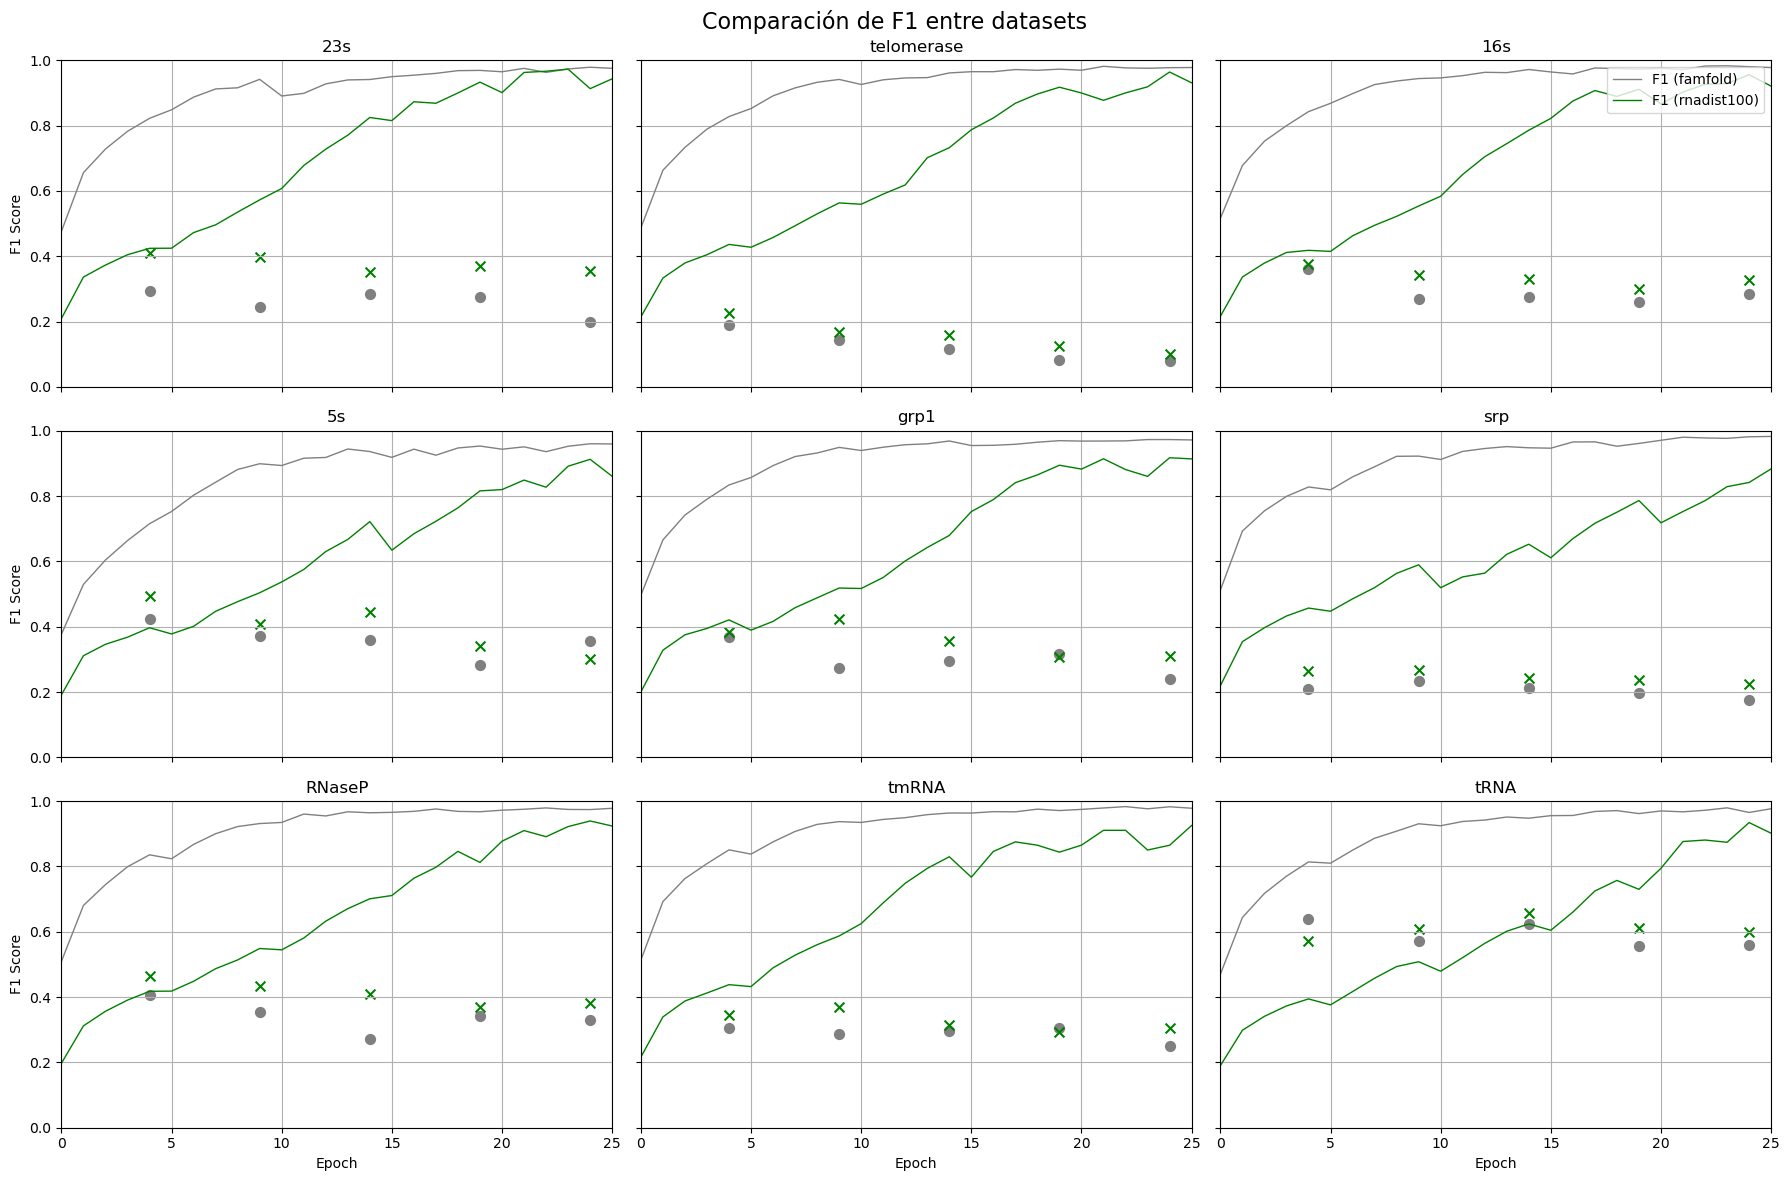

In [146]:

plot_f1_across_datasets(
    datasets=[dfs1, dfs2 ],
    dataset_names=["famfold","rnadist100" ],
    fams=fams
)


# Famfold vs rnadist

/tmp/ipykernel_2979725/1321327669.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


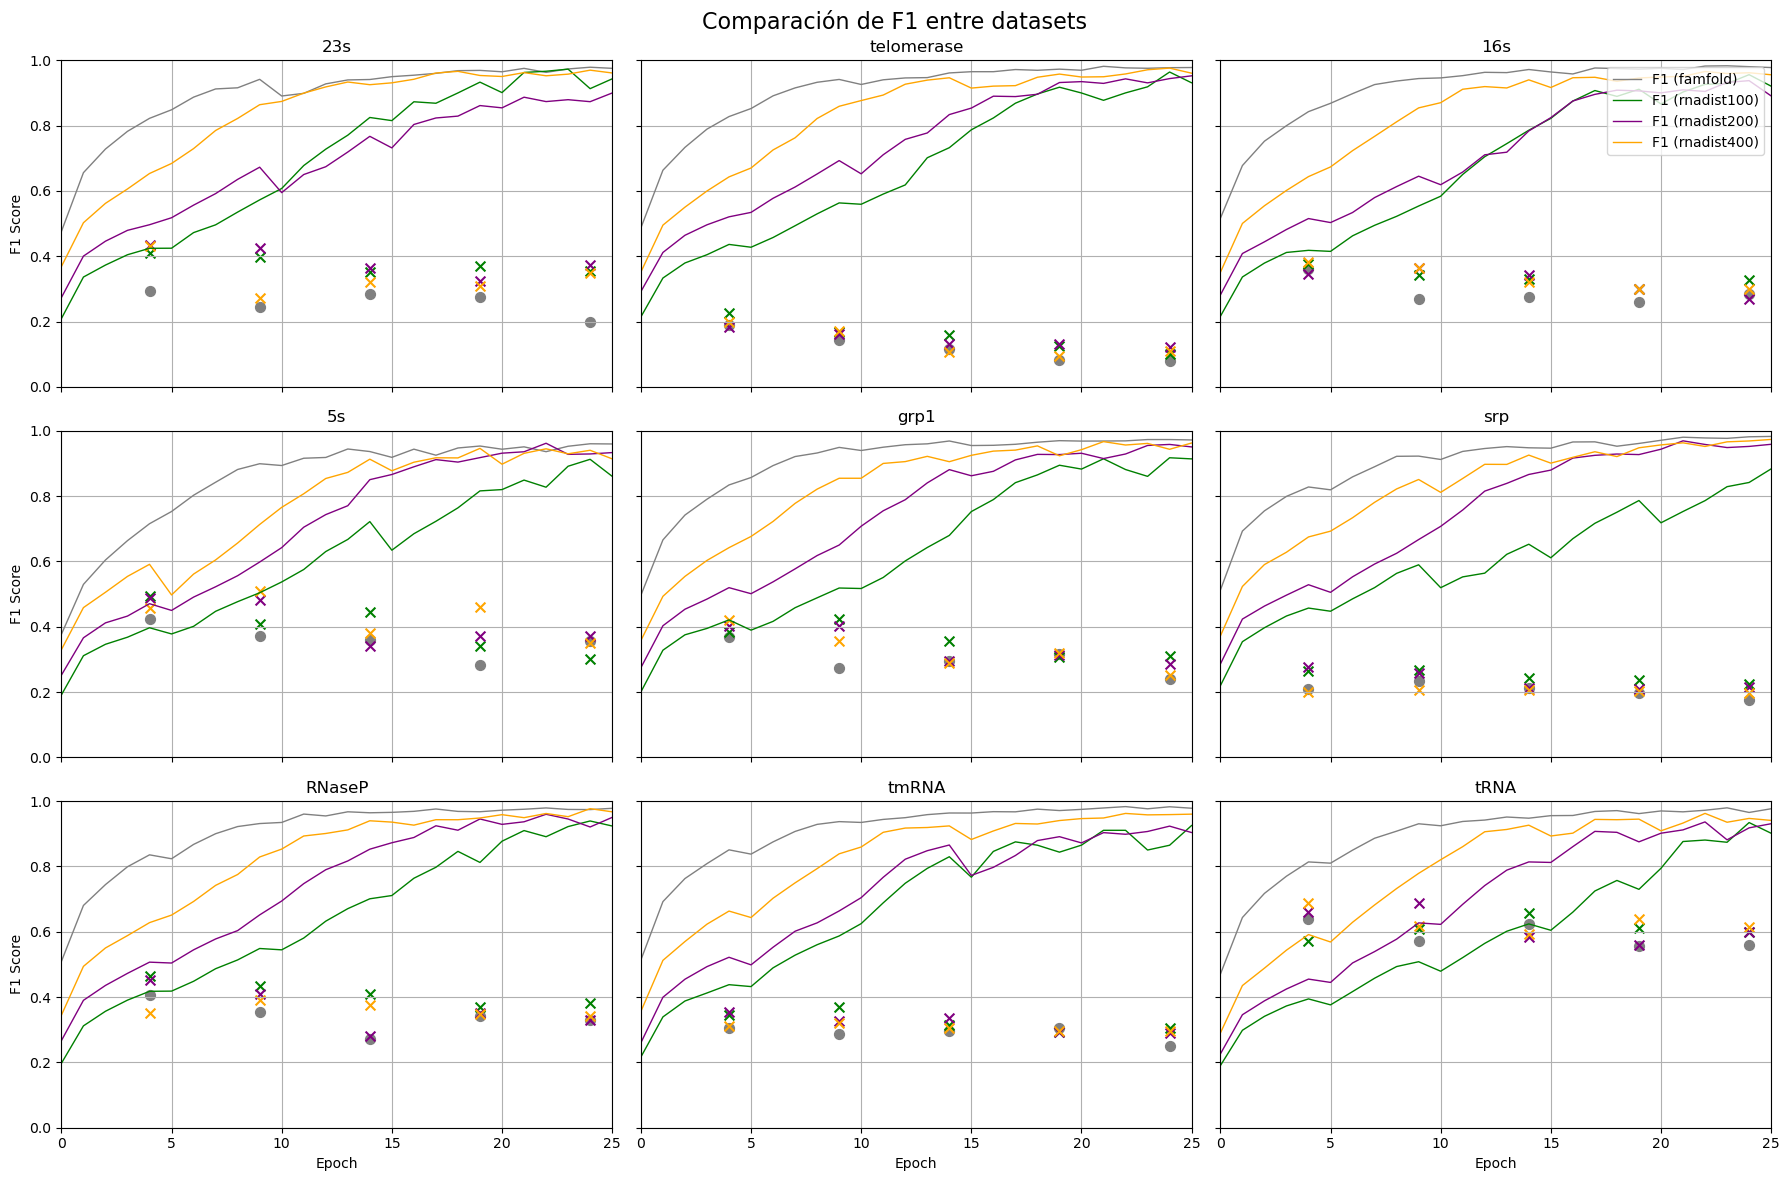

/tmp/ipykernel_2979725/3267640619.py:74: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


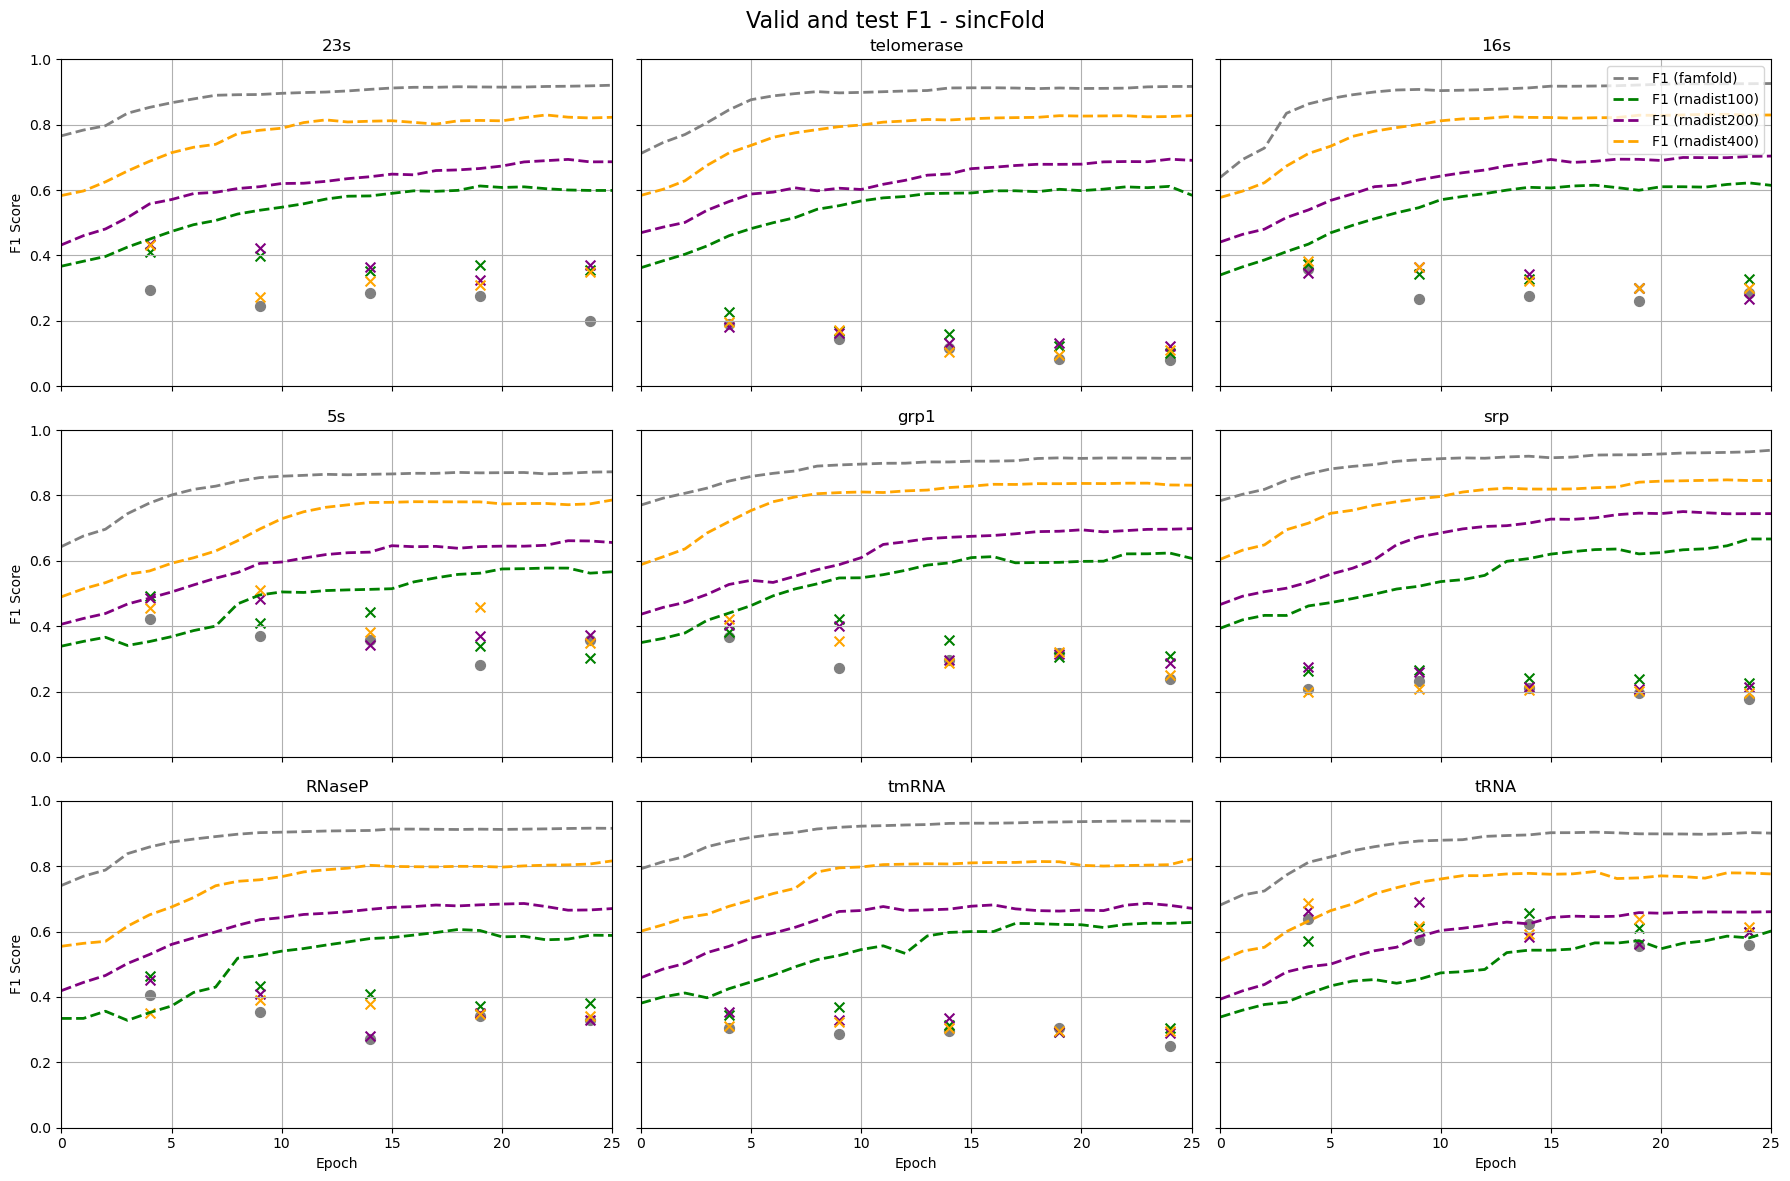

/tmp/ipykernel_2979725/3926715628.py:78: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


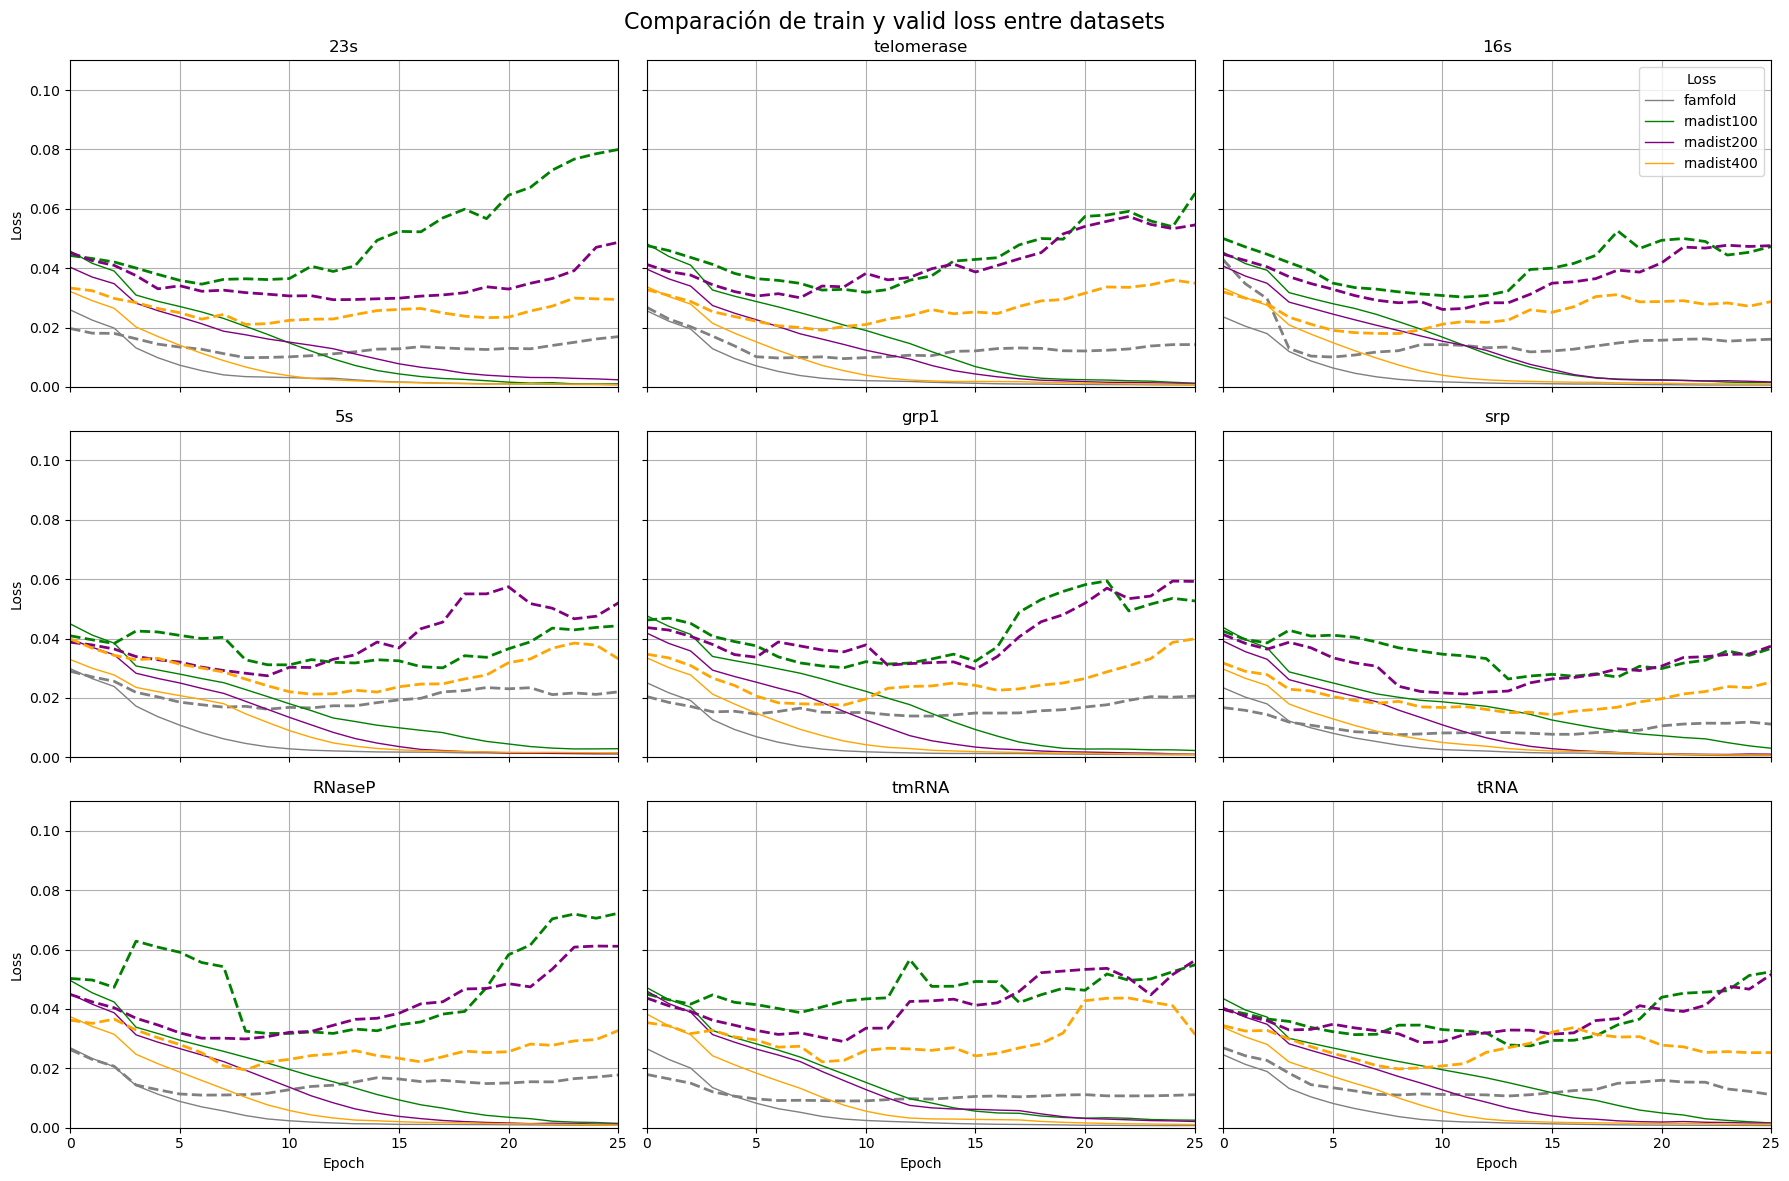

In [147]:
dataset_names = ["famfold","rnadist100", "rnadist200", "rnadist400",]
df_list = [dfs_all[k] for k in dataset_names]

plot_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)
plot_valid_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)

plot_loss_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams,
)

# famfold vs hc

/tmp/ipykernel_2979725/1321327669.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


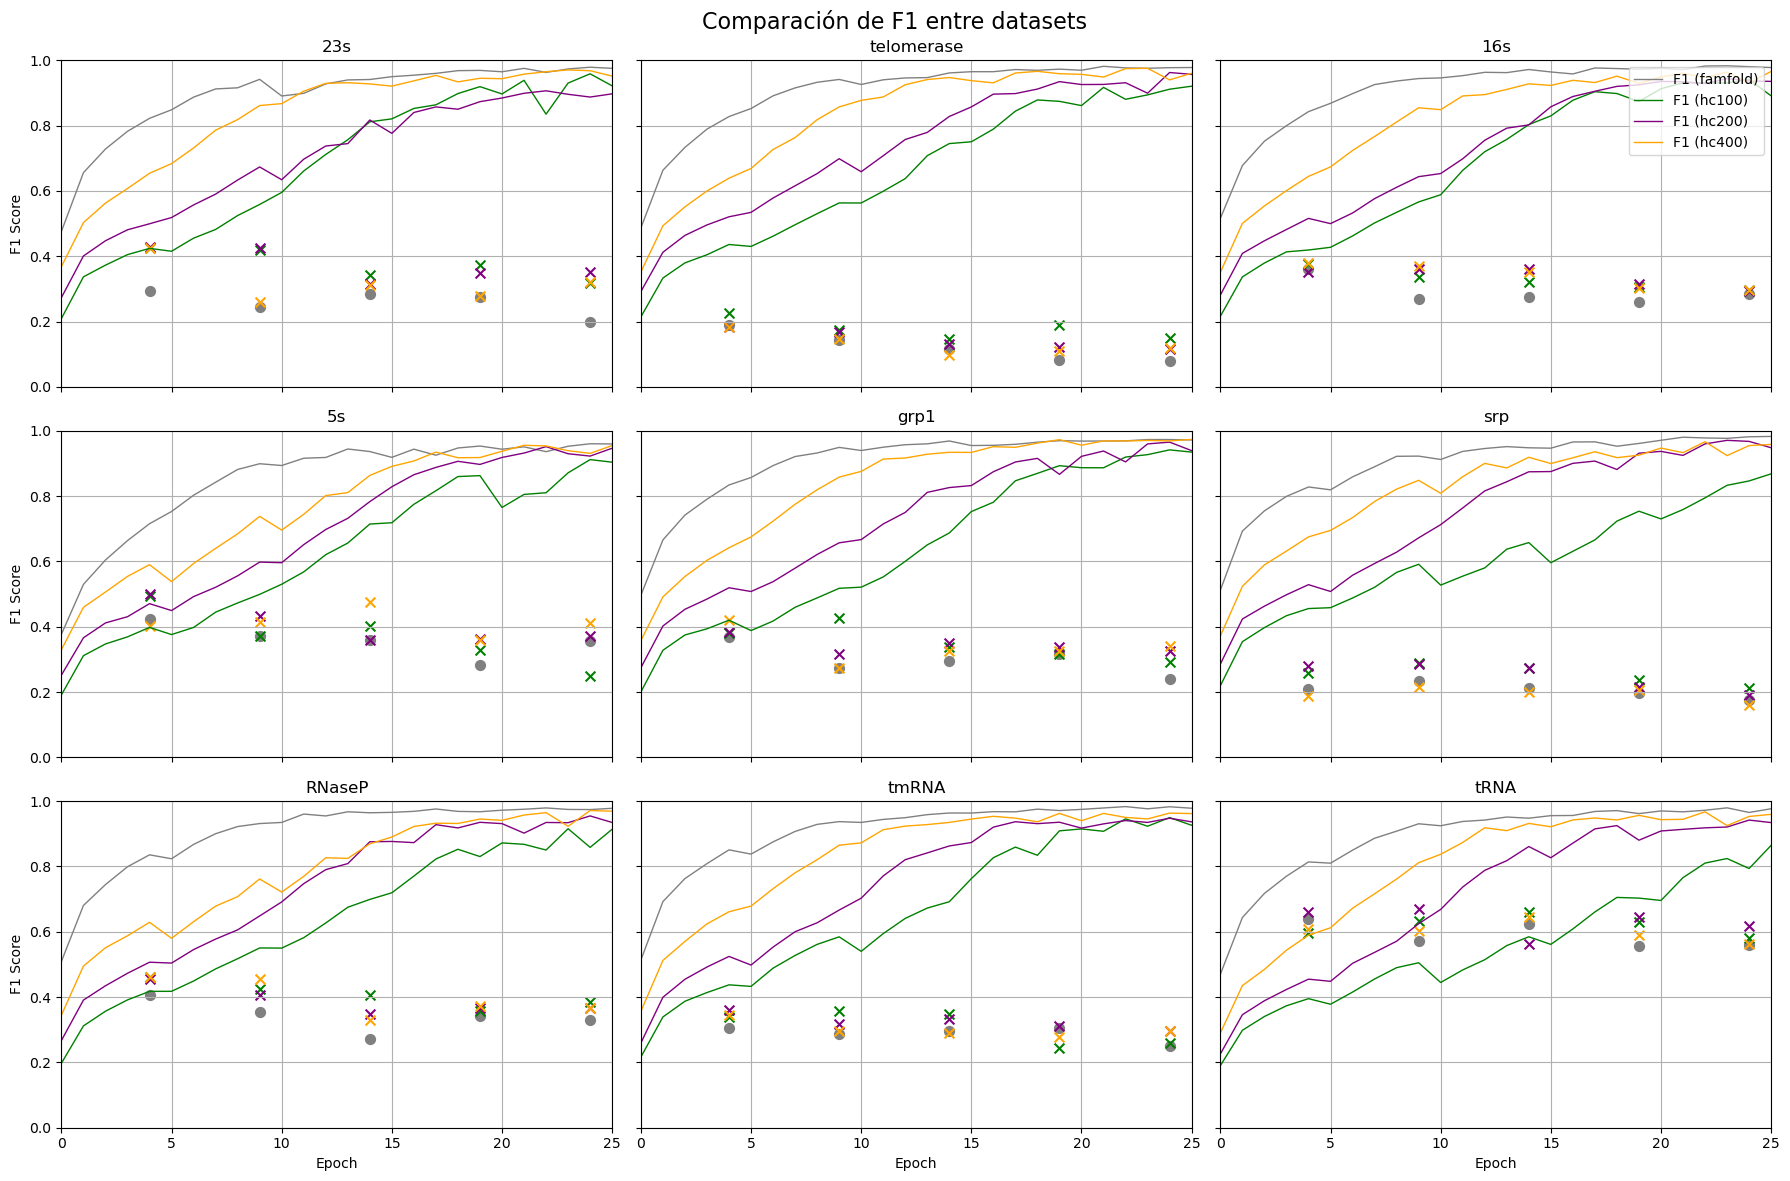

/tmp/ipykernel_2979725/3267640619.py:74: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


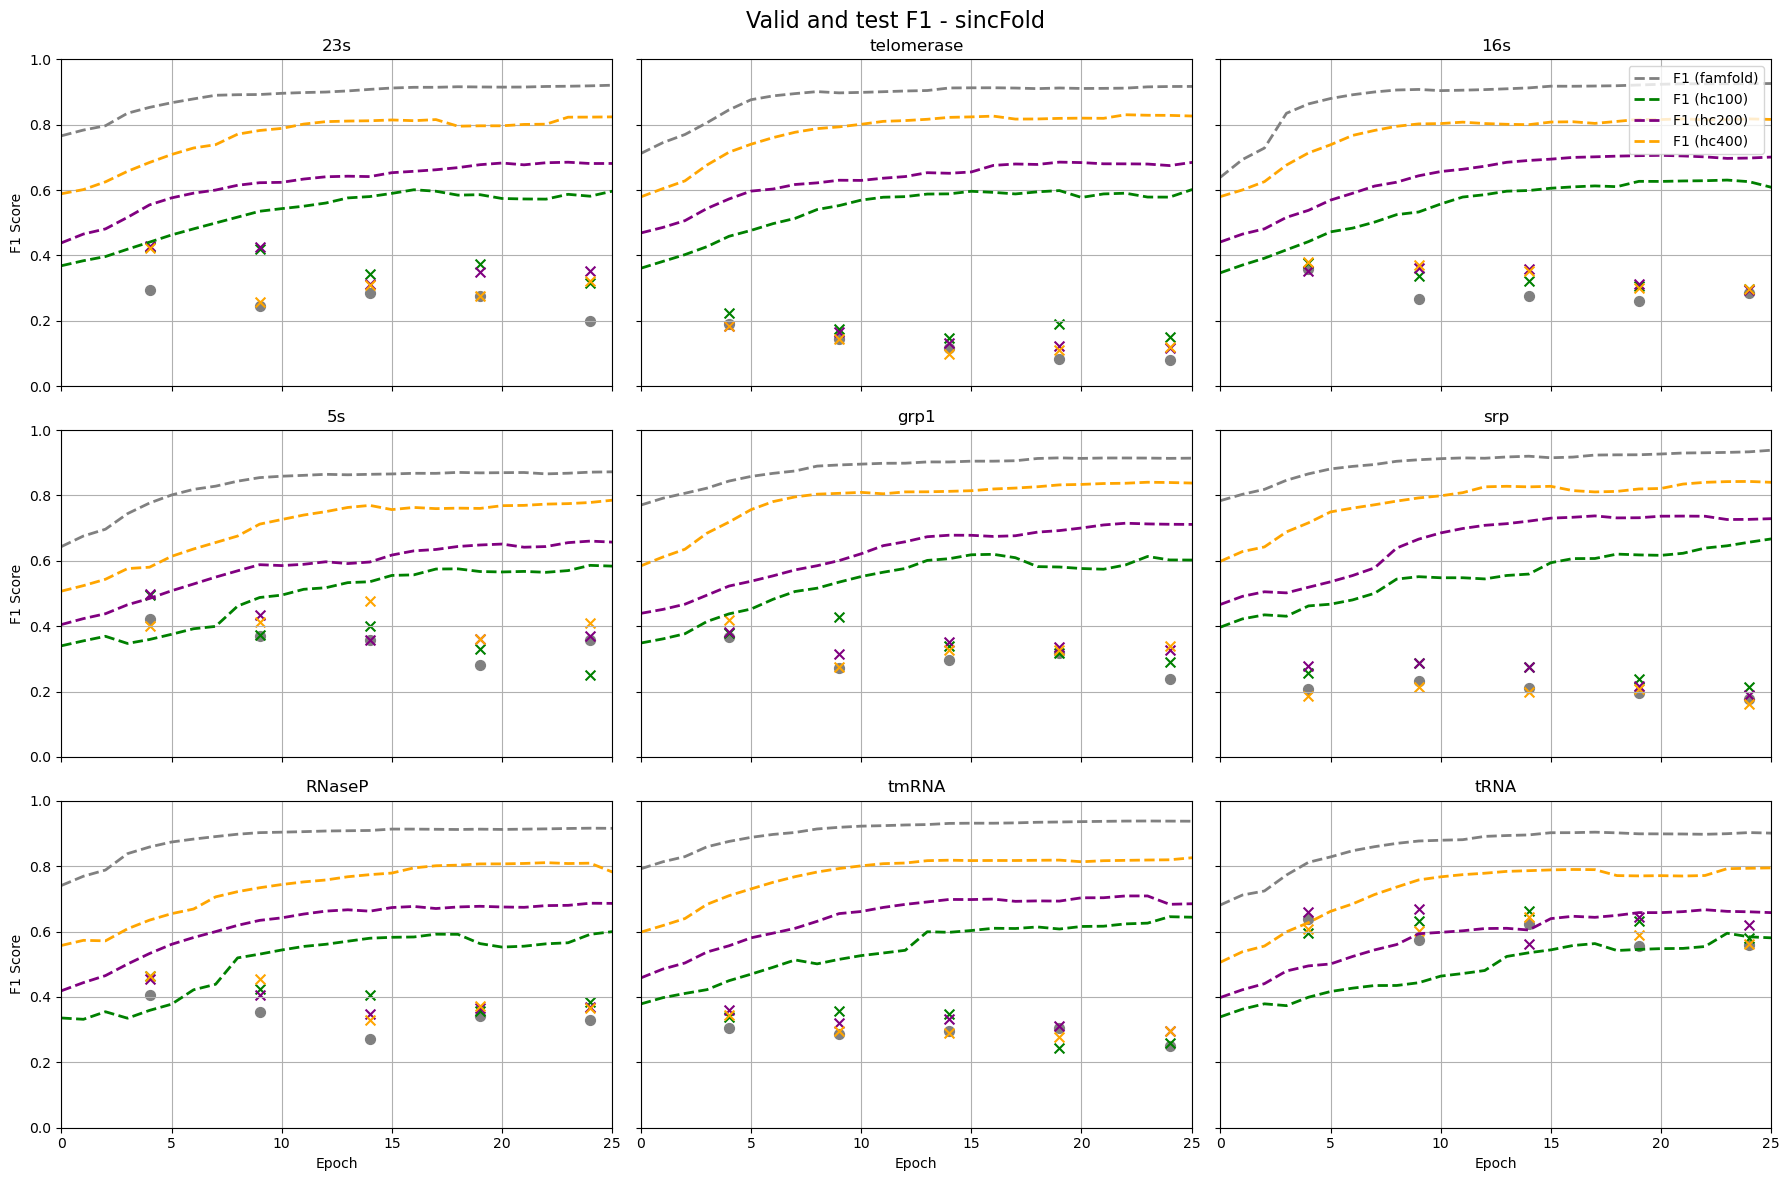

/tmp/ipykernel_2979725/3926715628.py:78: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


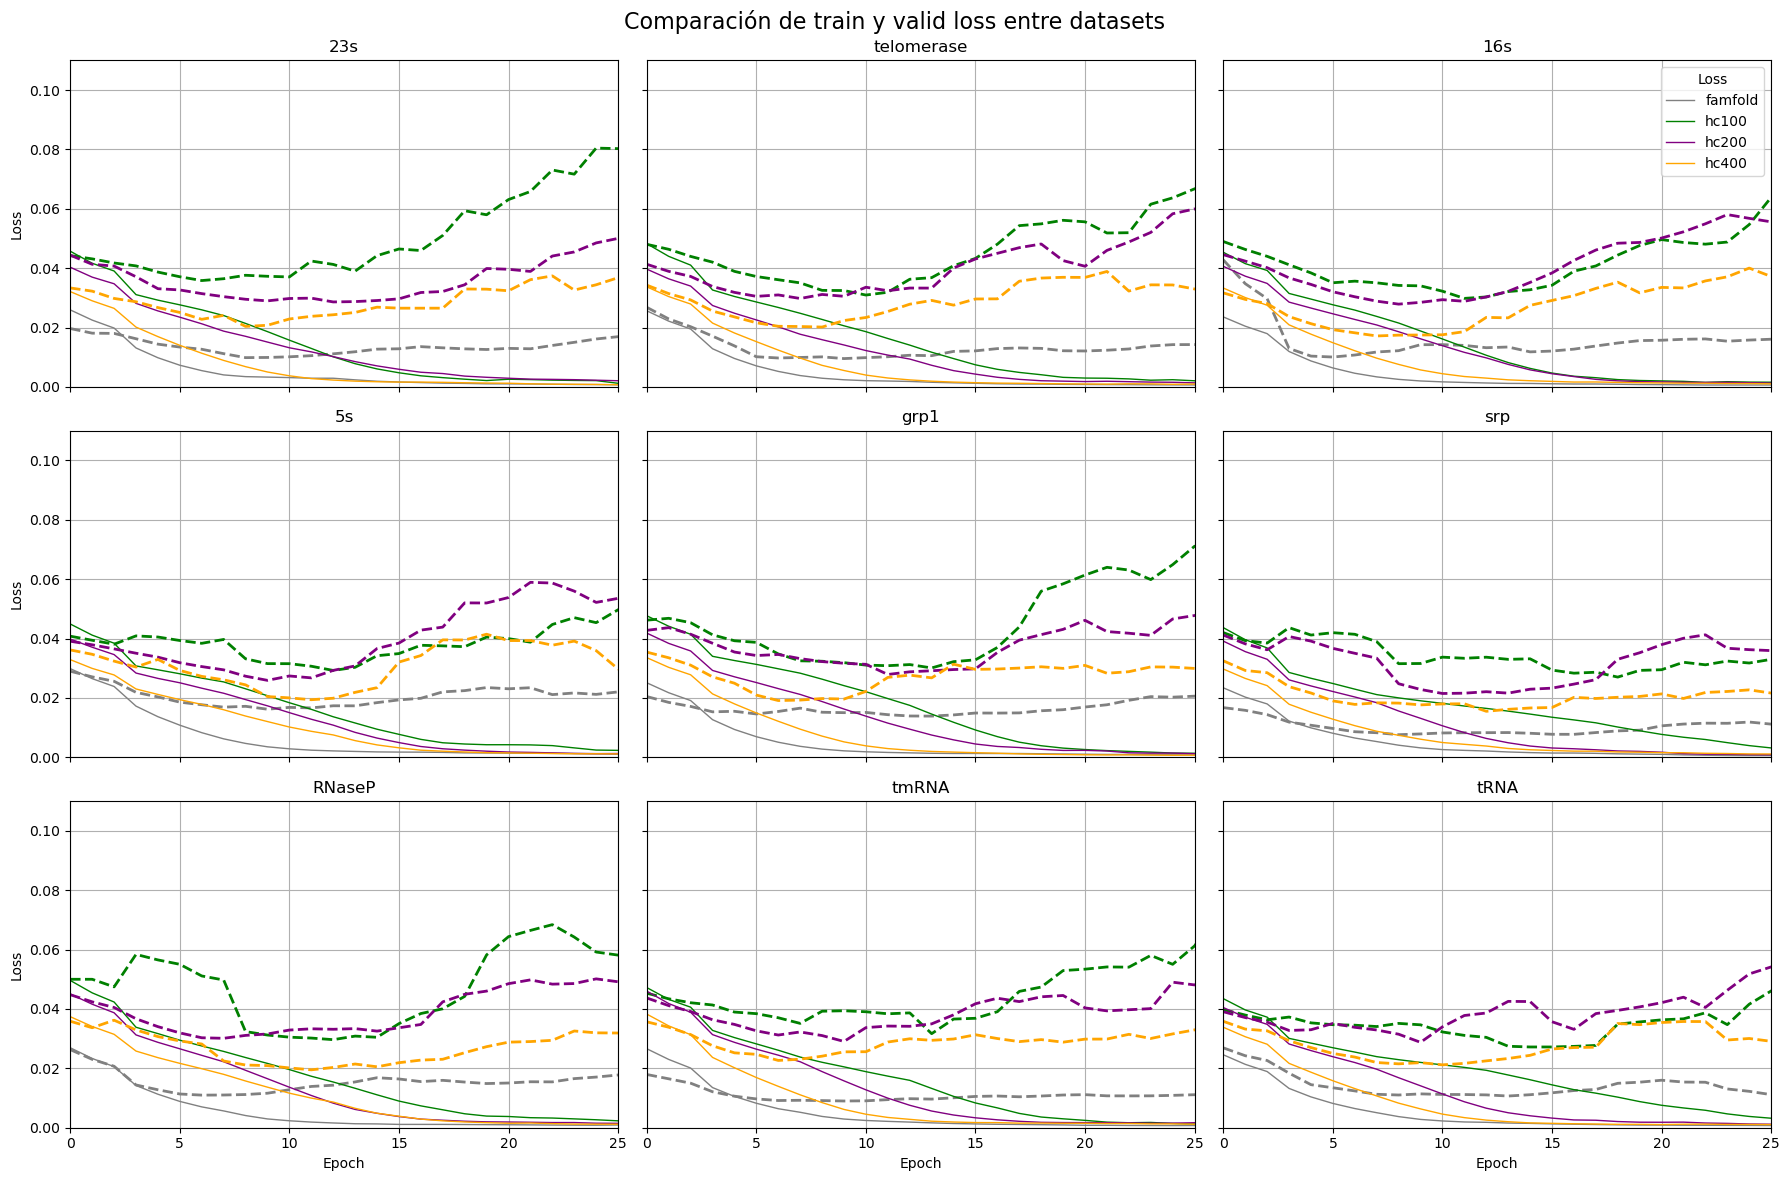

In [148]:
dataset_names = ["famfold","hc100", "hc200", "hc400",]
df_list = [dfs_all[k] for k in dataset_names]

plot_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)
plot_valid_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)

plot_loss_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams,
)

# famfold vs samples

/tmp/ipykernel_2979725/1321327669.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


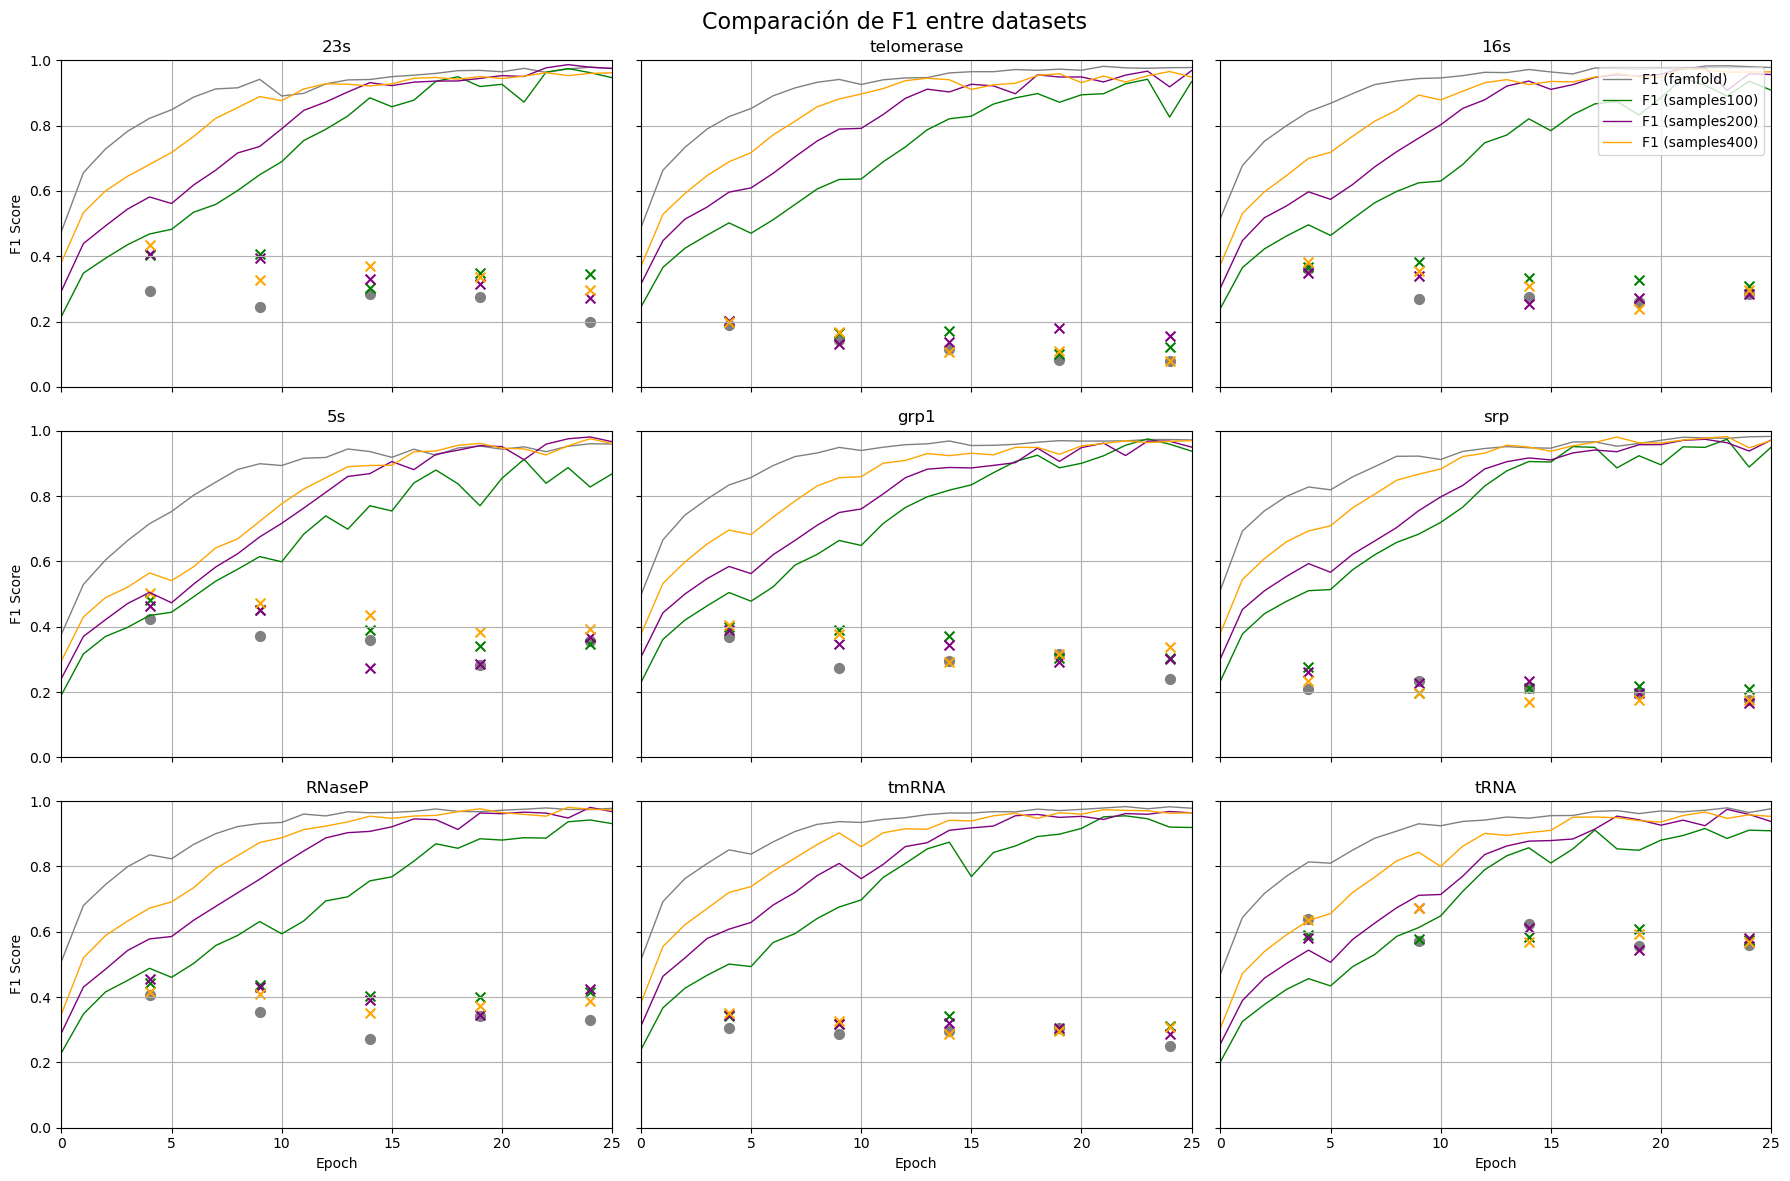

/tmp/ipykernel_2979725/3267640619.py:74: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


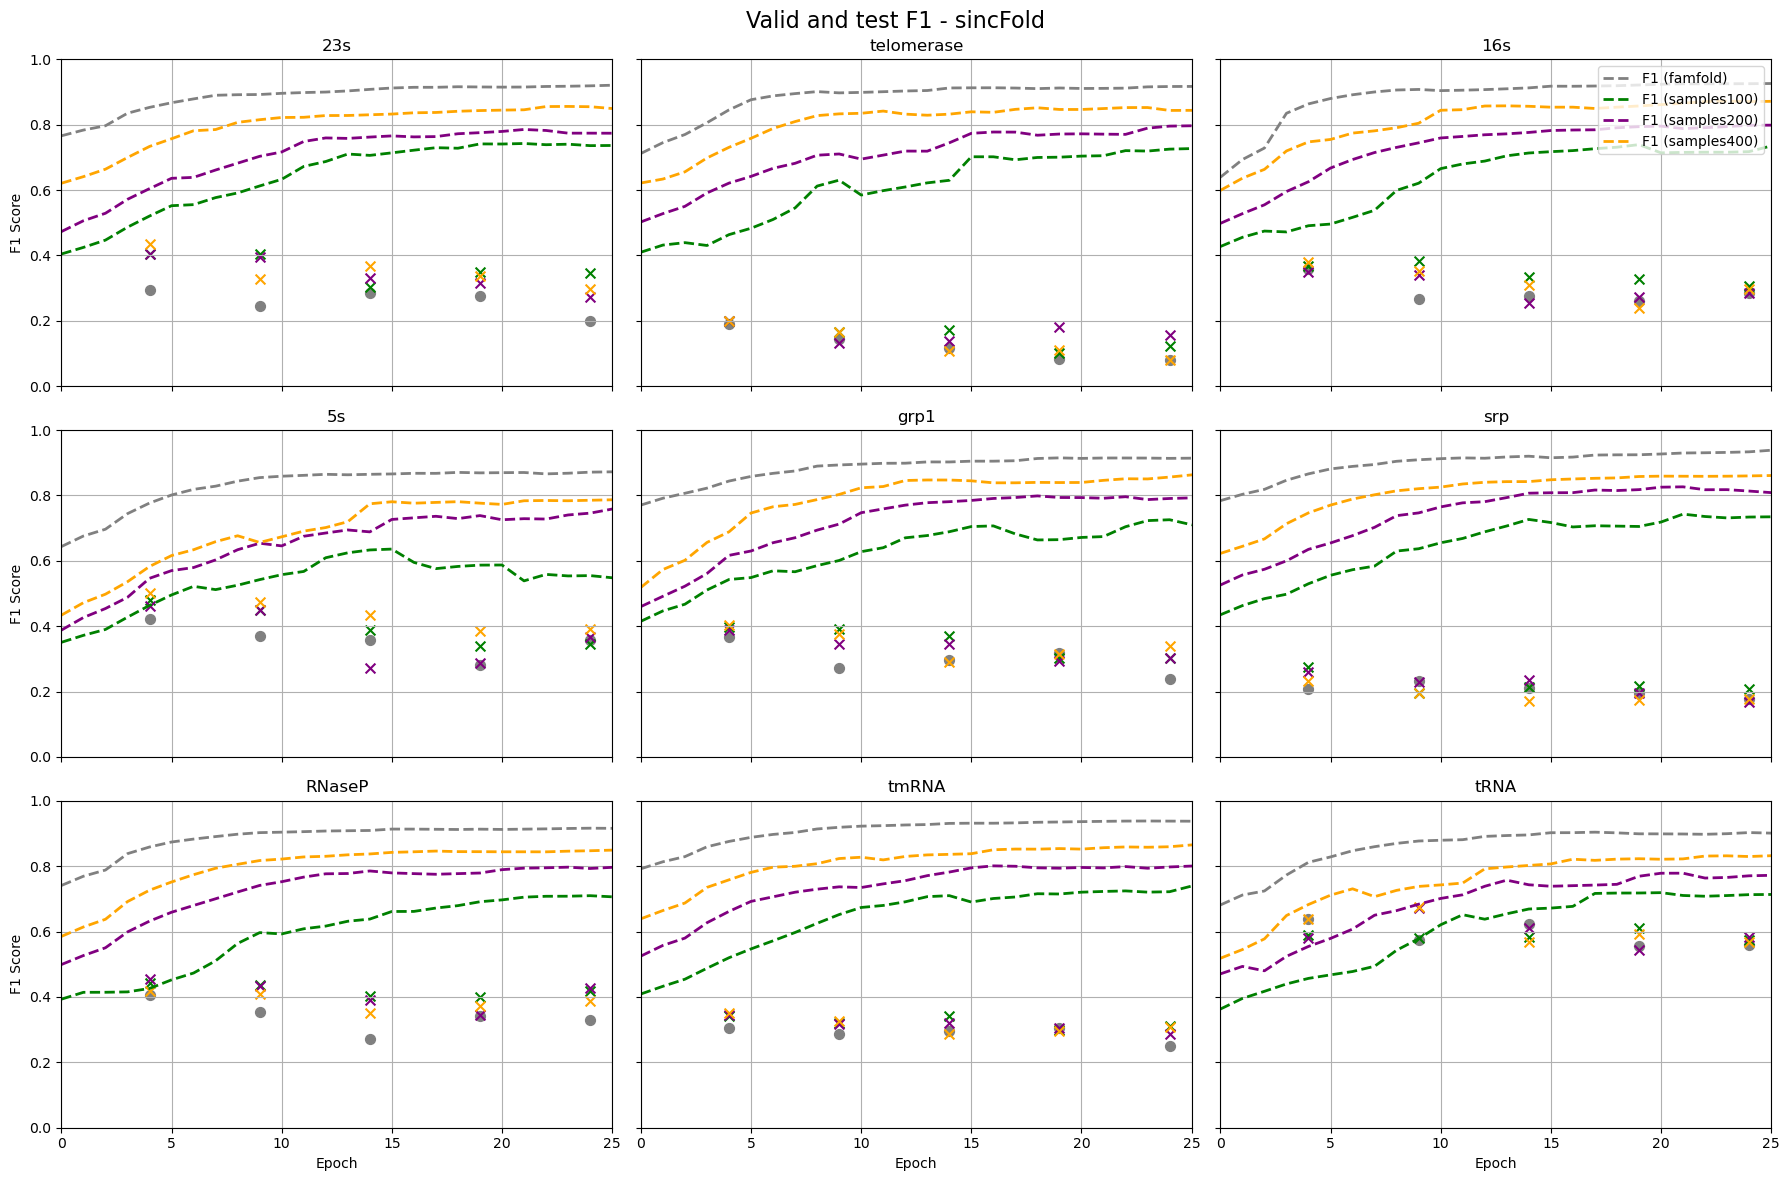

/tmp/ipykernel_2979725/3926715628.py:78: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


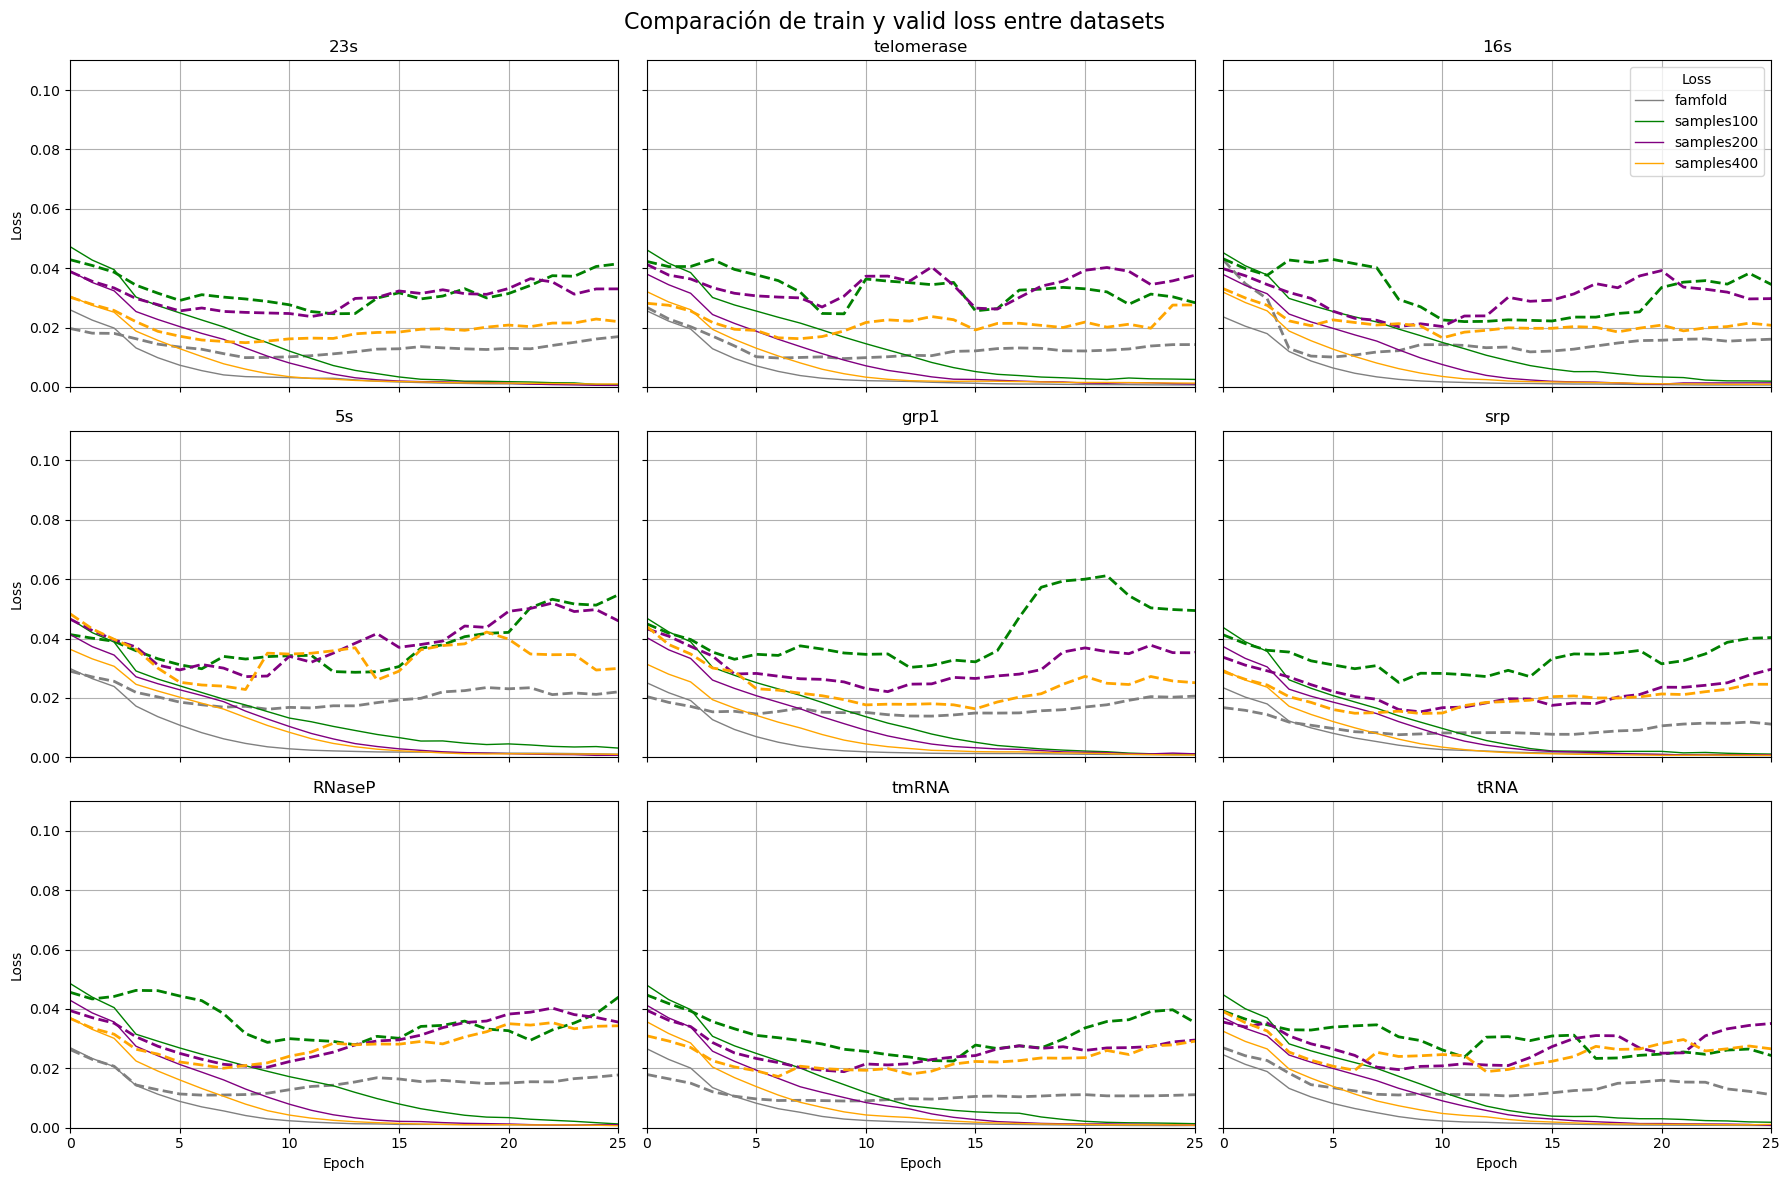

In [149]:
dataset_names = ["famfold","samples100", "samples200", "samples400",]
df_list = [dfs_all[k] for k in dataset_names]

plot_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)
plot_valid_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)

plot_loss_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams,
)

# famfold vs dist100

/tmp/ipykernel_2979725/1321327669.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


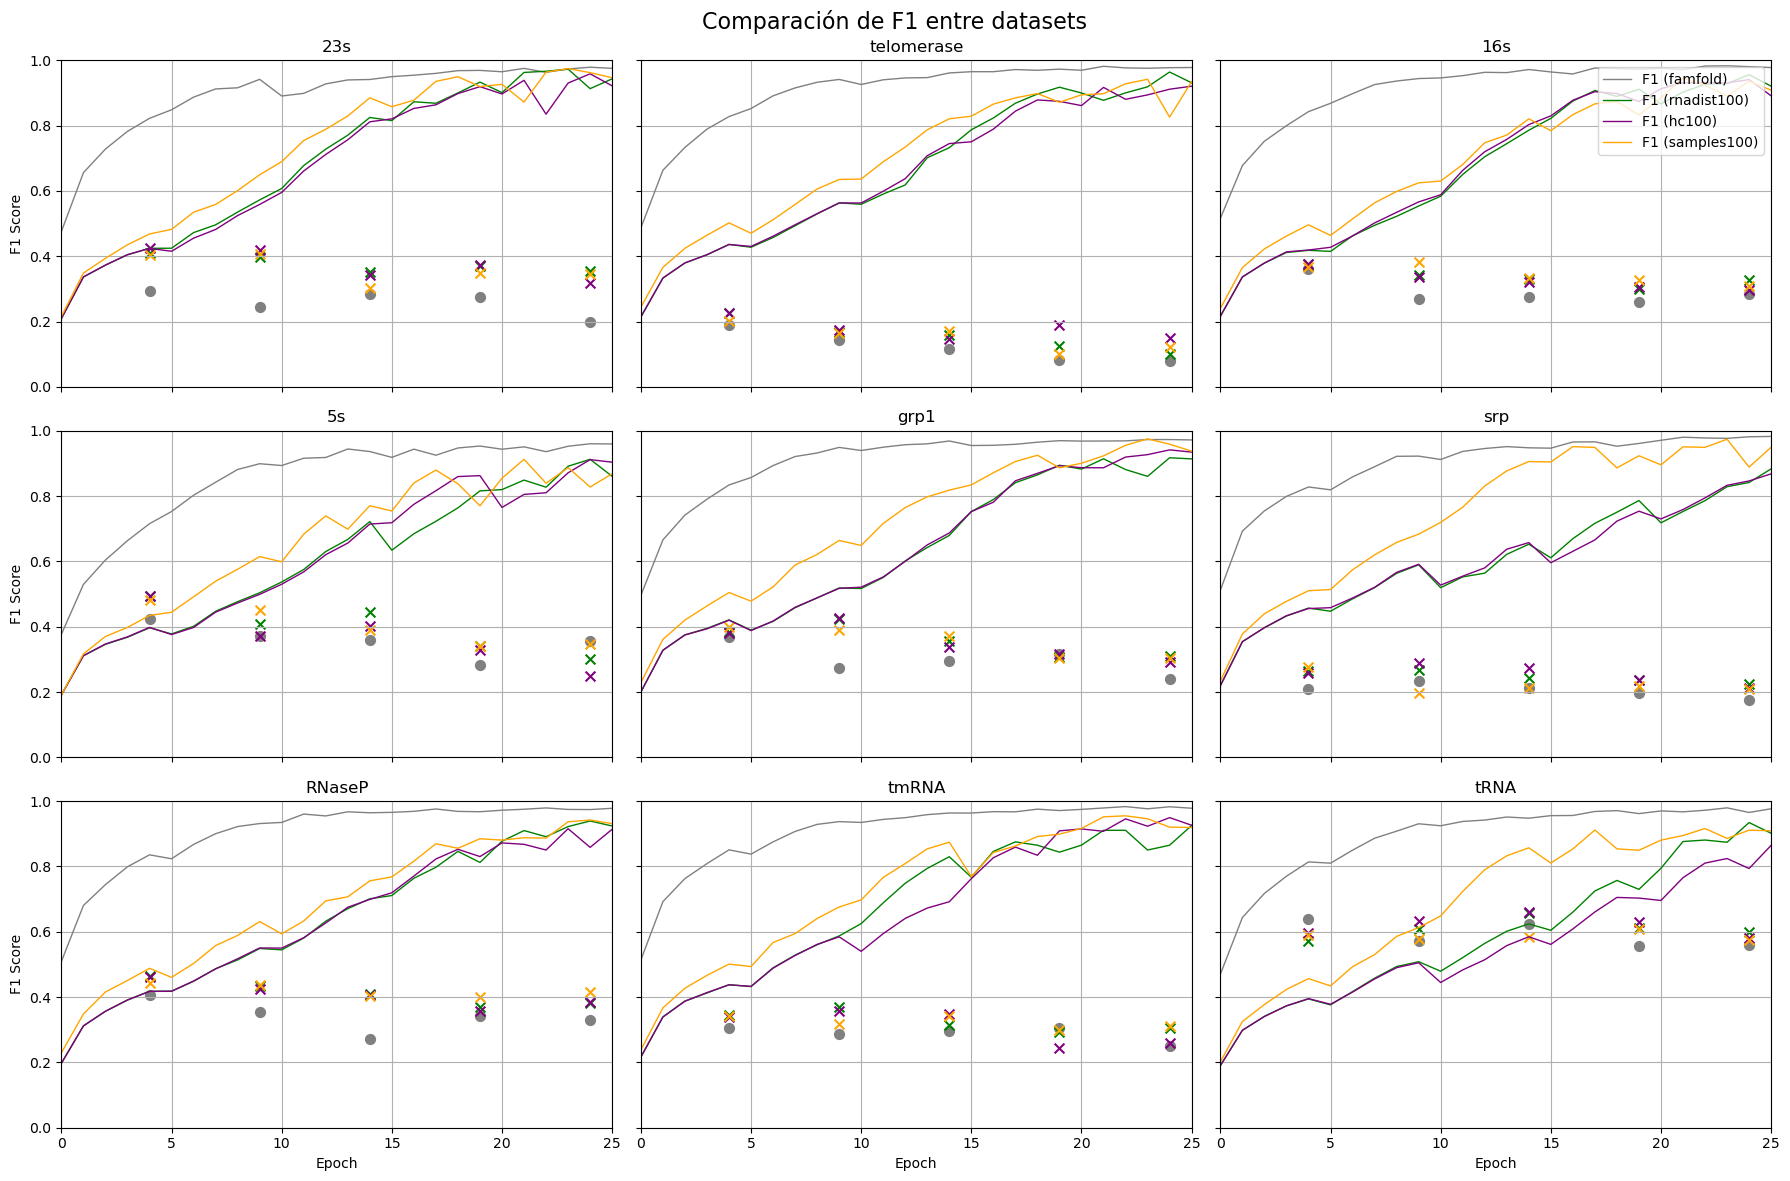

/tmp/ipykernel_2979725/3267640619.py:74: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


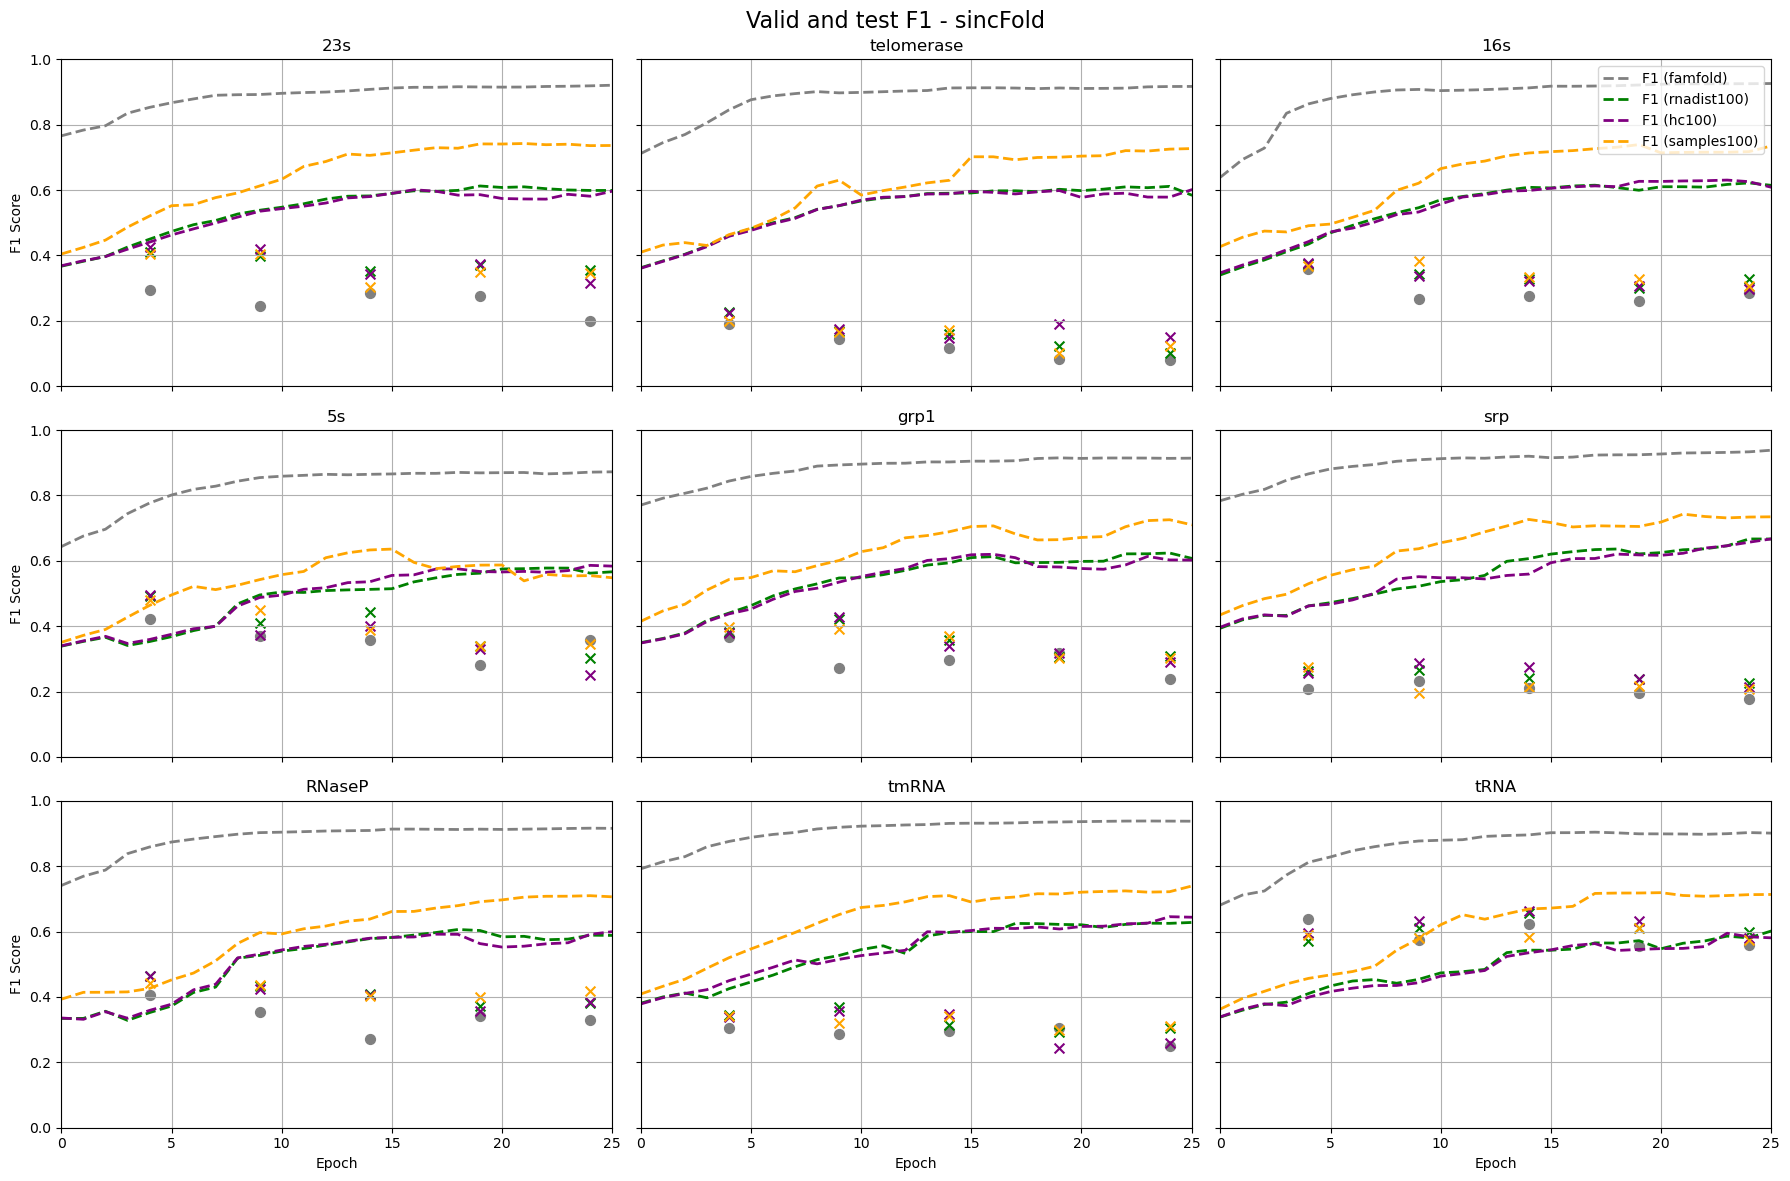

/tmp/ipykernel_2979725/3926715628.py:78: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


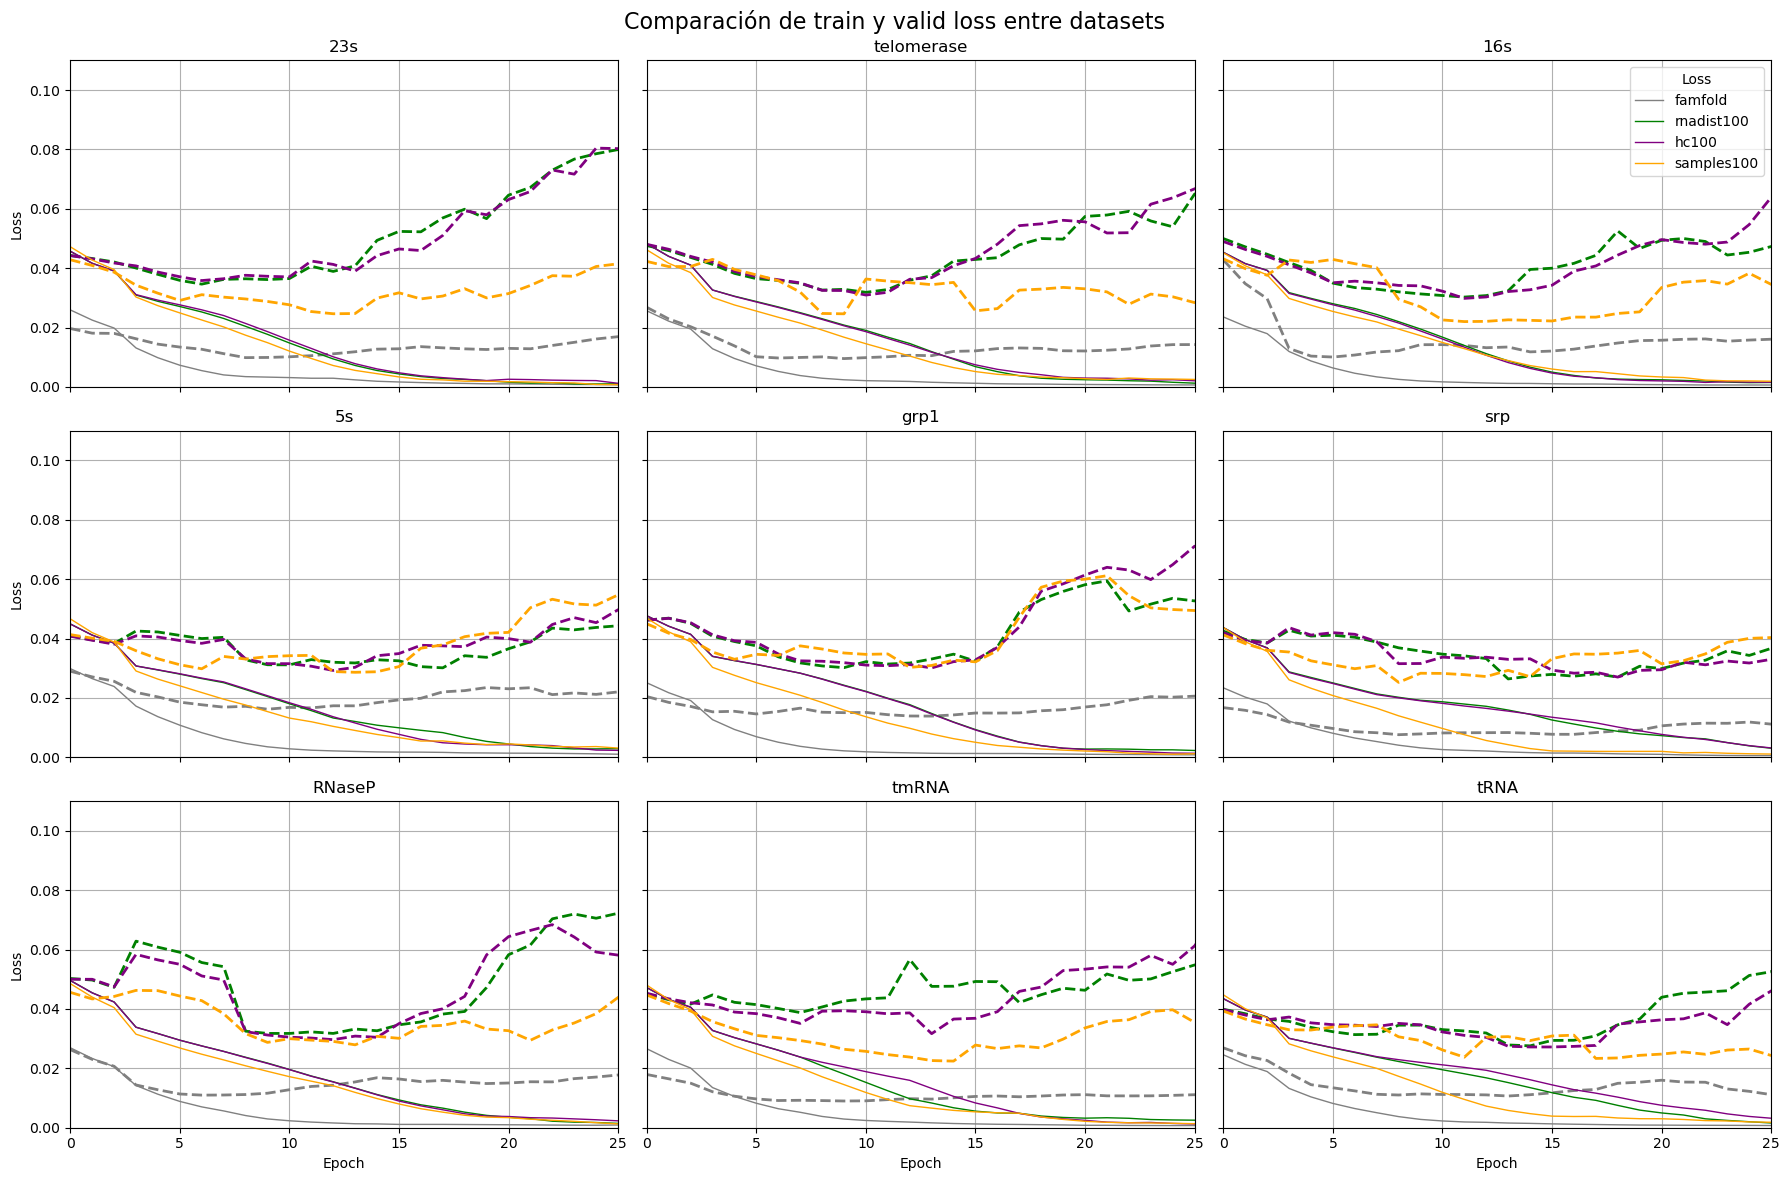

In [150]:
dataset_names = ["famfold","rnadist100", "hc100", "samples100",]
df_list = [dfs_all[k] for k in dataset_names]

plot_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)
plot_valid_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)

plot_loss_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams,
)

# famfold vs dist 200

/tmp/ipykernel_2979725/1321327669.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


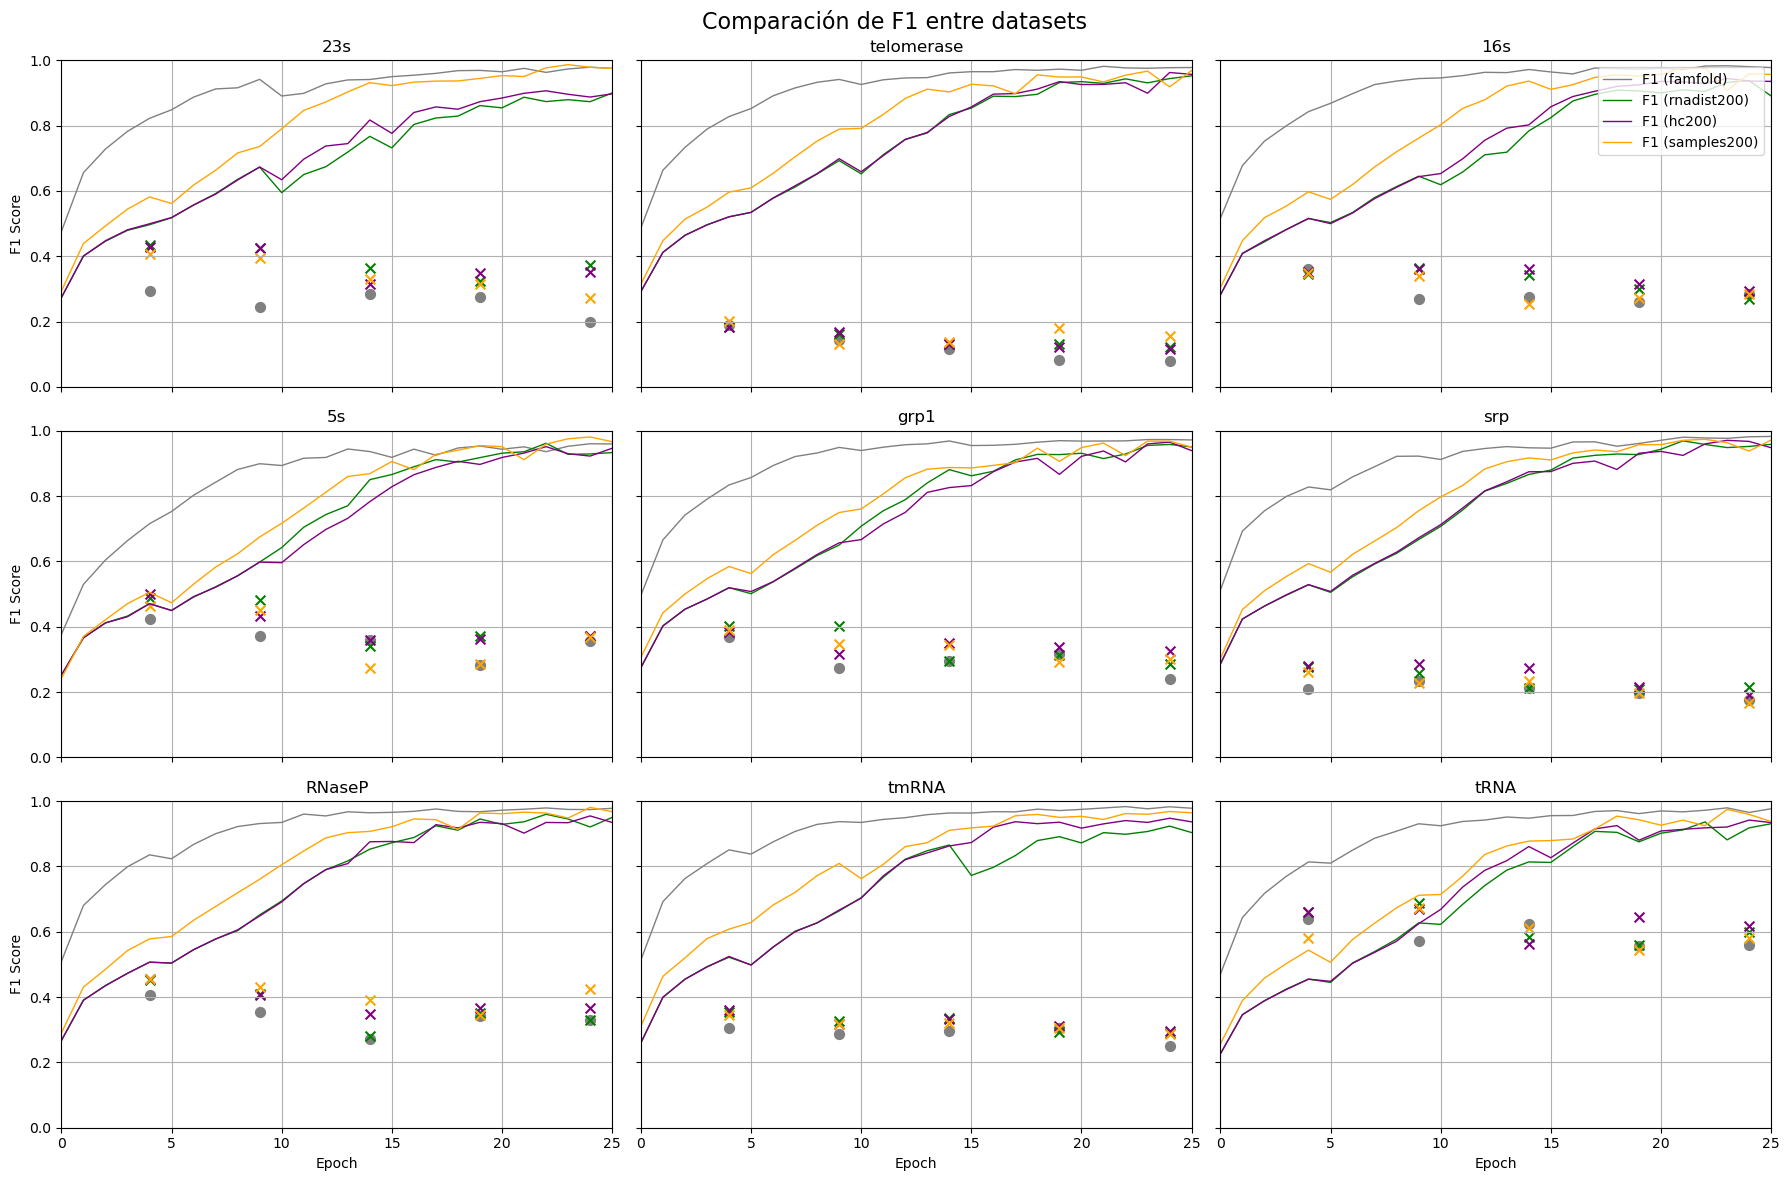

/tmp/ipykernel_2979725/3267640619.py:74: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


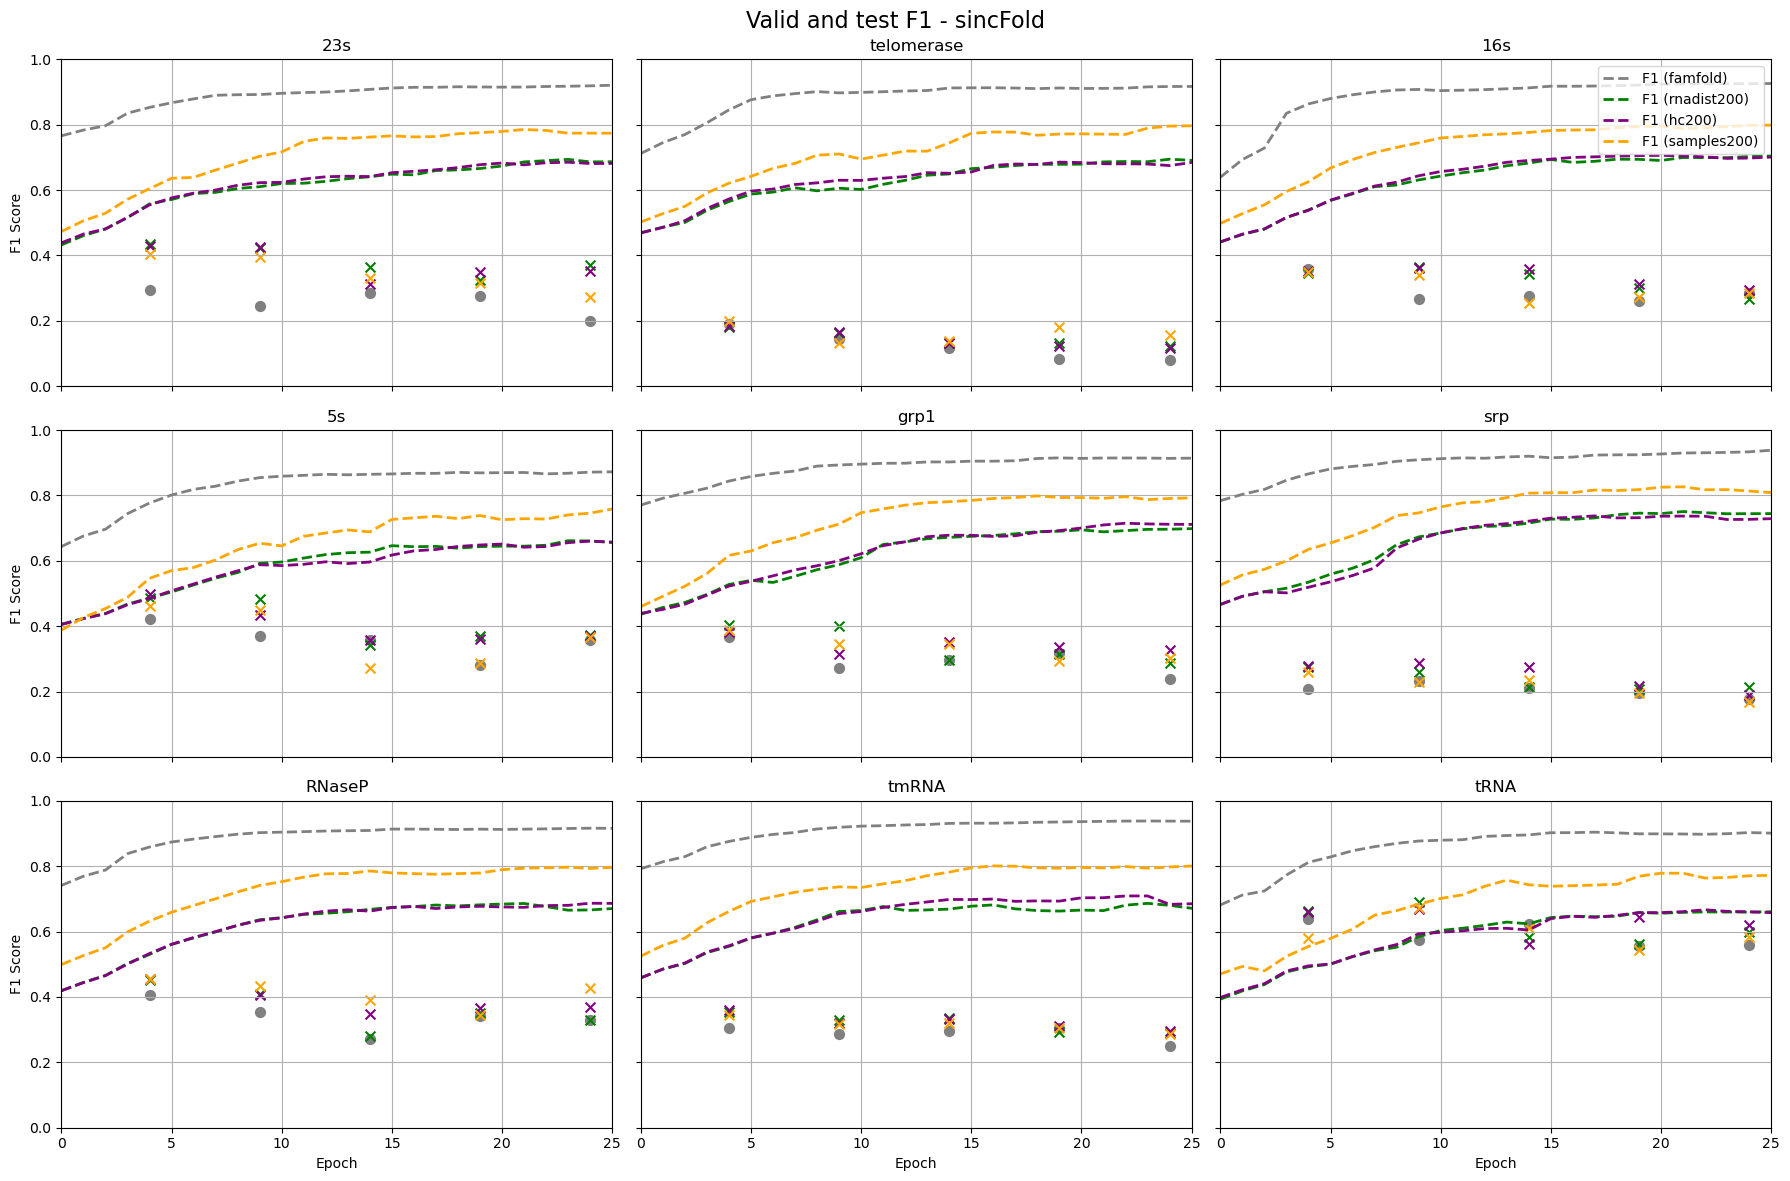

/tmp/ipykernel_2979725/3926715628.py:78: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


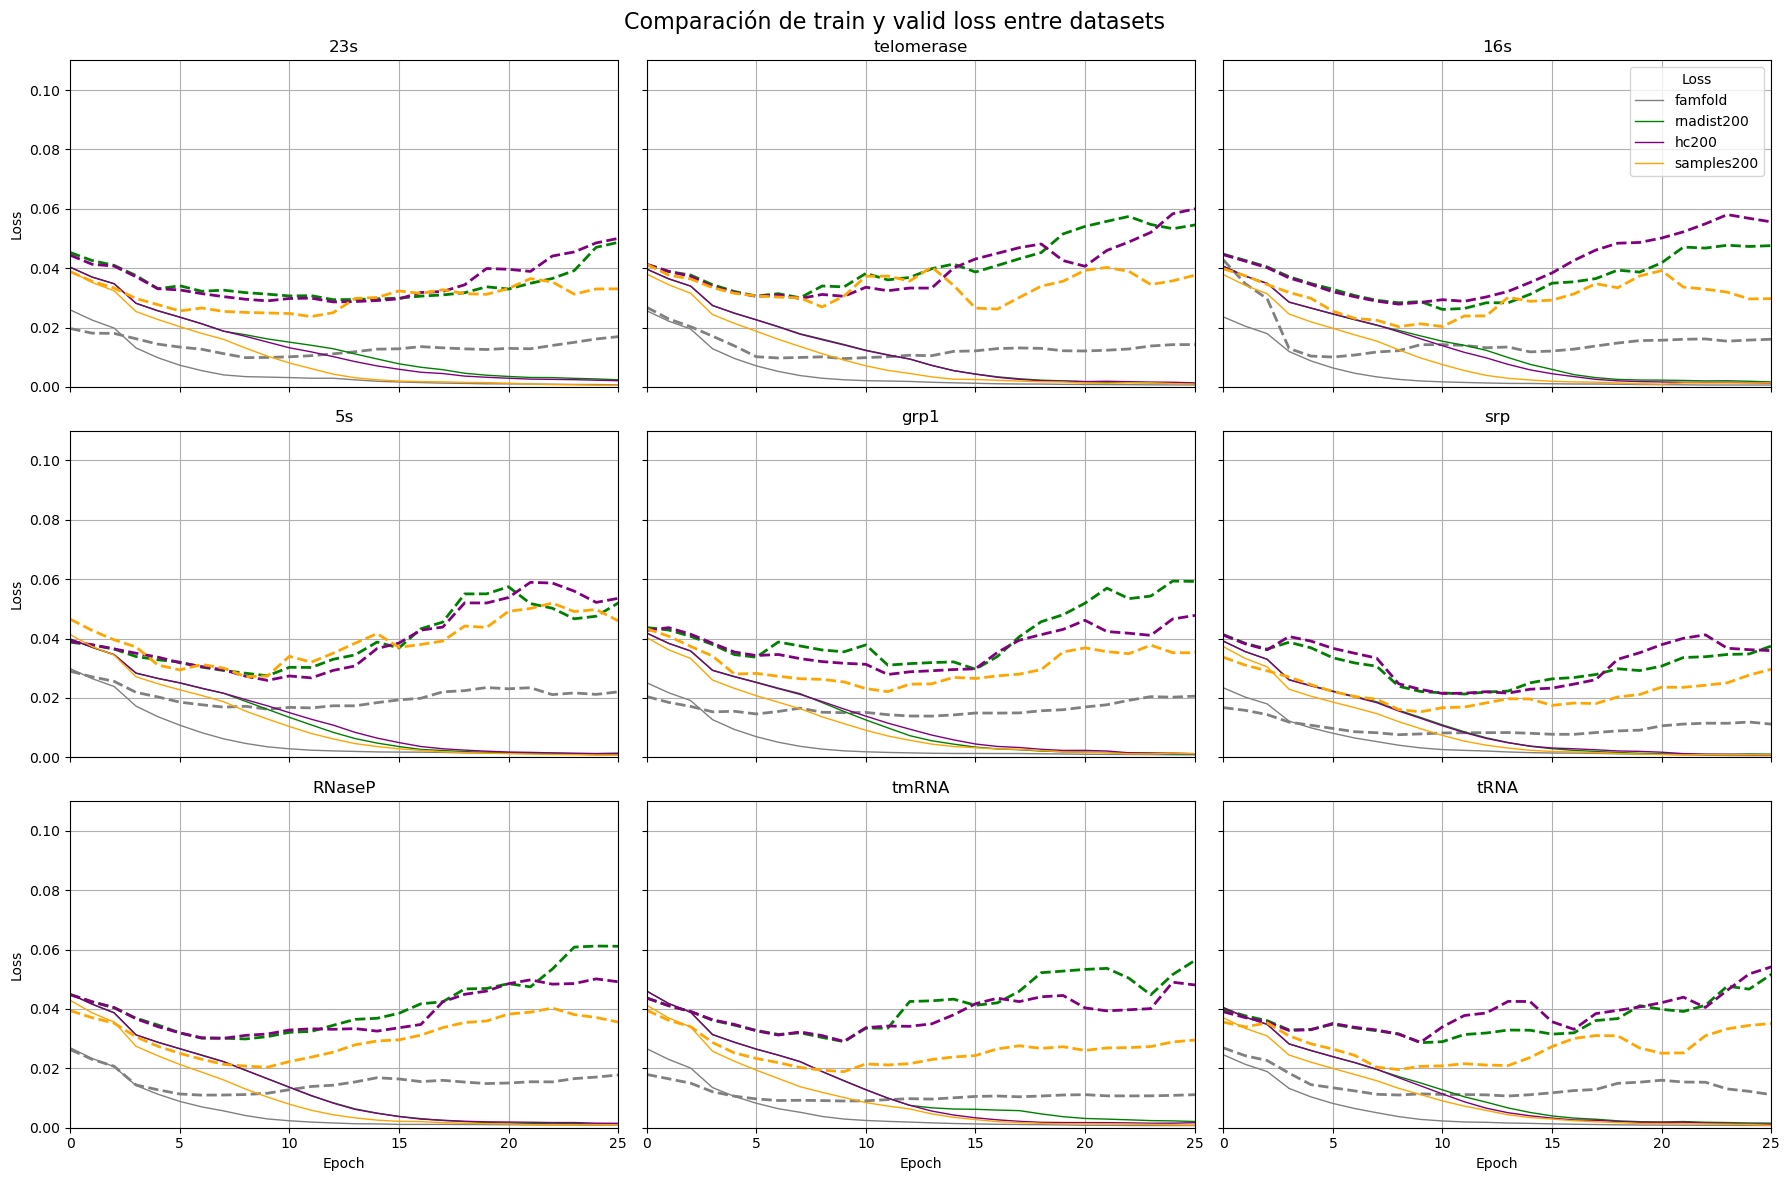

In [151]:
dataset_names = ["famfold","rnadist200", "hc200", "samples200",]
df_list = [dfs_all[k] for k in dataset_names]
plot_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)
plot_valid_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)

plot_loss_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams,
)

# famfold vs dist 400

/tmp/ipykernel_2979725/1321327669.py:77: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


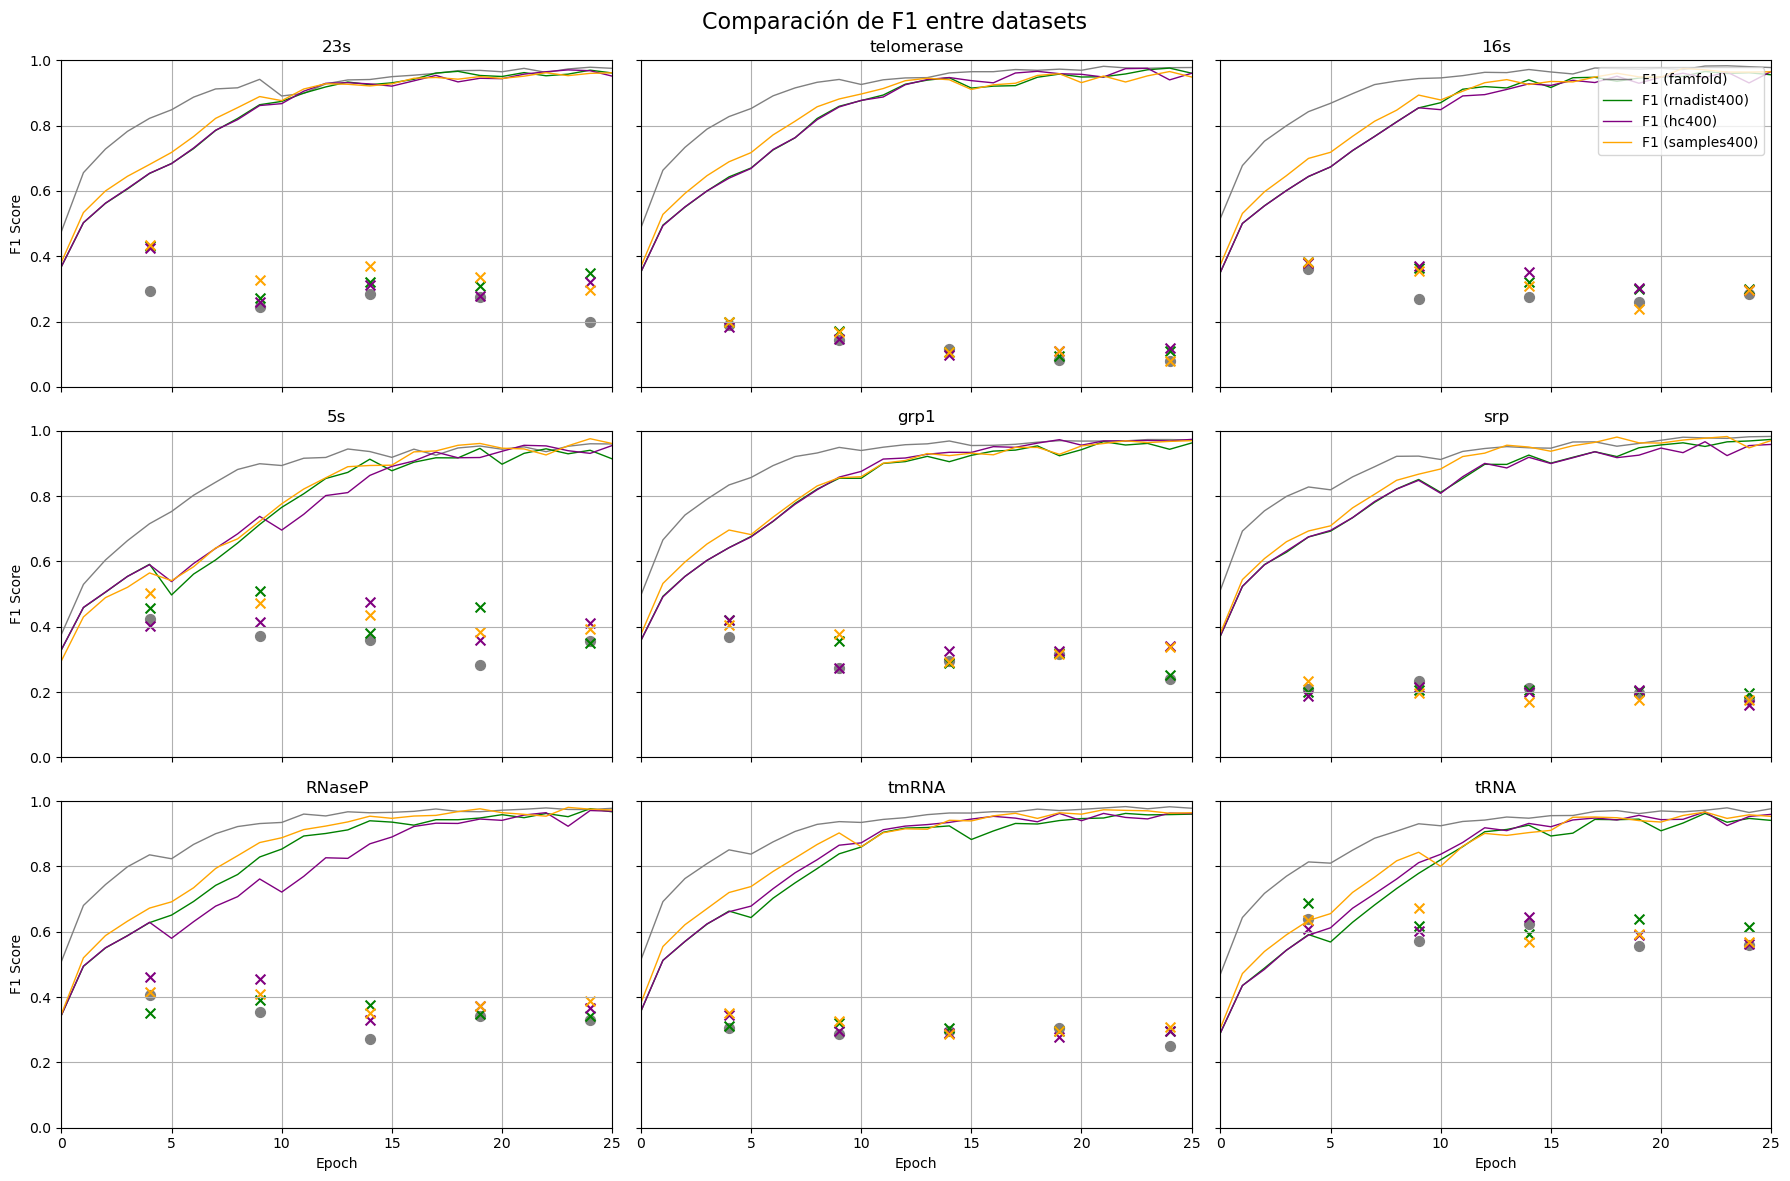

/tmp/ipykernel_2979725/3267640619.py:74: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


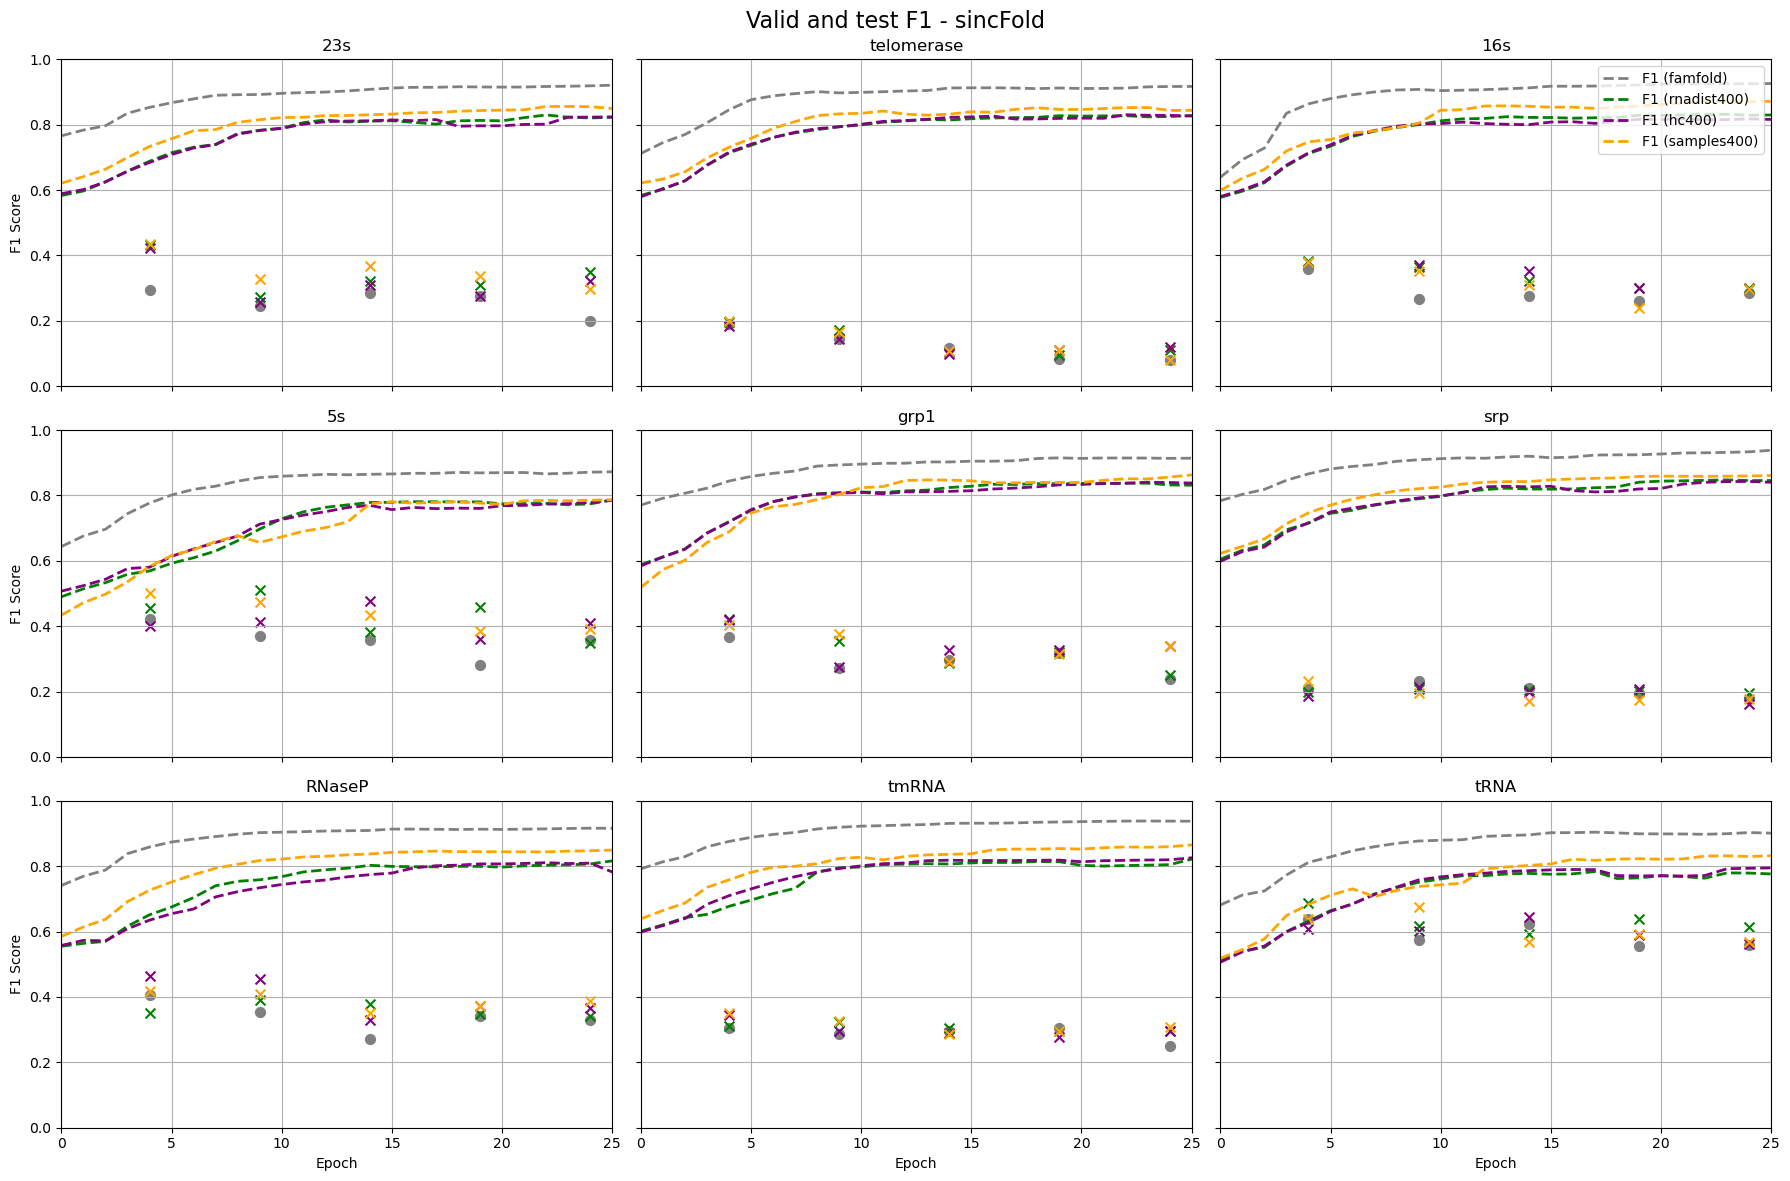

/tmp/ipykernel_2979725/3926715628.py:78: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


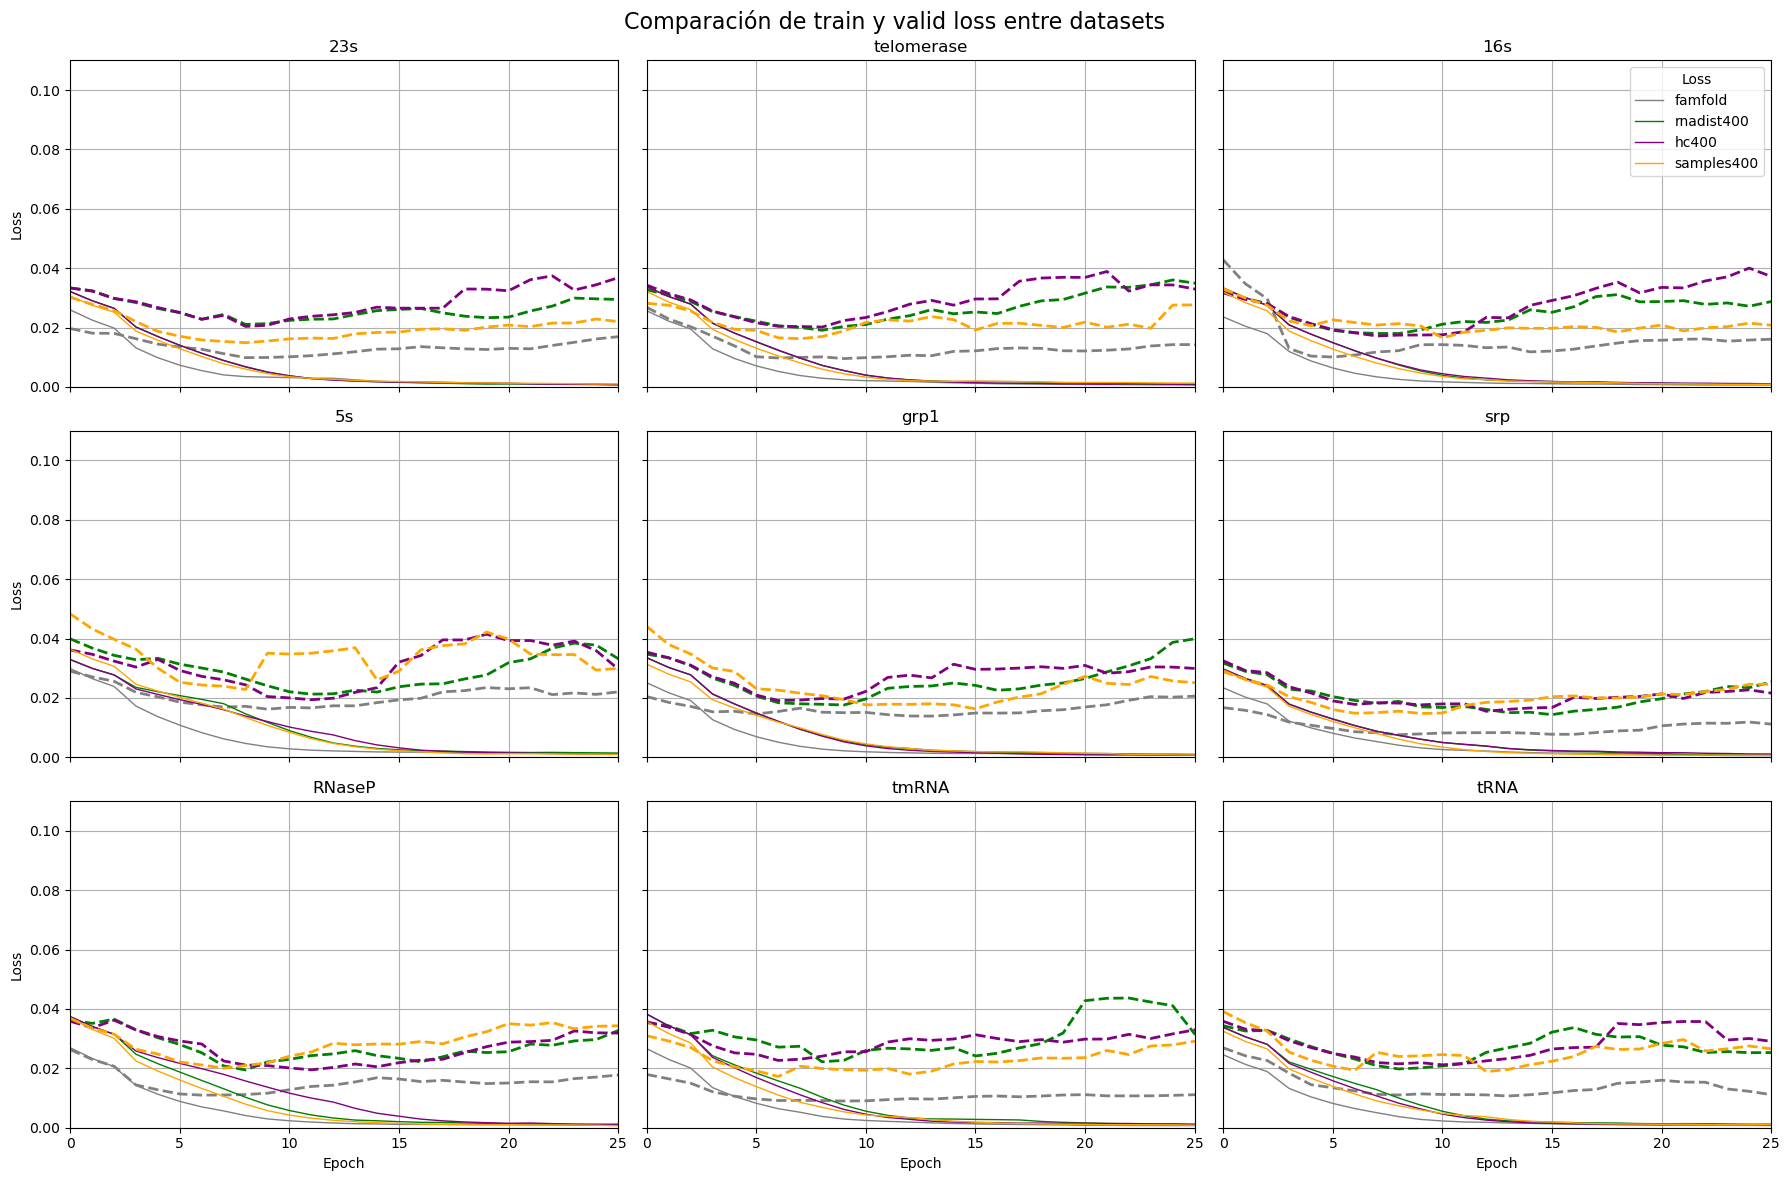

In [152]:
dataset_names = ["famfold","rnadist400", "hc400", "samples400",]
df_list = [dfs_all[k] for k in dataset_names]

plot_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)
plot_valid_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)

plot_loss_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams,
)

In [153]:
def plot_valid_f1_across_datasets(datasets, dataset_names, fams, cols=3, figsize=(6, 4), dist_plot=False, save=False): 
    
    n_fams = len(fams)
    rows = (n_fams + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0]*cols, figsize[1]*rows),
                             constrained_layout=True, sharex=True, sharey=True)
    axes = axes.flatten()

    # paleta consistente
    if dist_plot:
        base_colors = ['gray', 'brown', 'blue', "#42f084"]
    else:
        base_colors = ['gray', 'green', 'purple', 'orange', 'brown', 'blue']

    for ax, fam in zip(axes, fams):
        for i, (dfs, name) in enumerate(zip(datasets, dataset_names)):
            df = dfs[fam]

            color = base_colors[i % len(base_colors)] 

            # Train F1
            if name =="famfold":
                name ="famfold"
            else:
                name = name[:-3]
            ax.plot(df['epoch'], df['valid_f1_post'], label=f'{name}',
                    color=color, linewidth=1, )

            # Test F1 post
            test_rows = df['f1_post'].notna()
            ax.scatter(df.loc[test_rows, 'epoch'], df.loc[test_rows, 'f1_post'],
                       color=color, s=50, marker='o' if i == 0 else 'x',
                       label=None)

        ax.set_title(f'{fam}', fontsize=16)
        ax.set_ylim(0, 1)
        ax.grid(True)

    # Ejes
    for n in range(0, len(axes), cols):
        axes[n].set_ylabel('F1 Score', fontsize=16)
        axes[n].tick_params(axis='y', labelsize=14)
    for n in range(len(axes) - cols, len(axes)):
        axes[n].set_xlabel('Epoch')
        axes[n].tick_params(axis='x', labelsize=14)

    # Leyenda solo en el último eje visible
    axes[2].legend(title="method",loc="upper right", fontsize=14, title_fontsize=16)

    # Ocultar sobrantes
    for ax in axes[n_fams:]:
        ax.set_visible(False)

    fig.suptitle("Valid and test F1 - Threshold: 100", fontsize=20)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURE_PATH + "sincfold_valid_F1_lr.pdf", dpi=300)
    plt.show()


## SAVE 100 - 

/tmp/ipykernel_2979725/1174034995.py:55: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


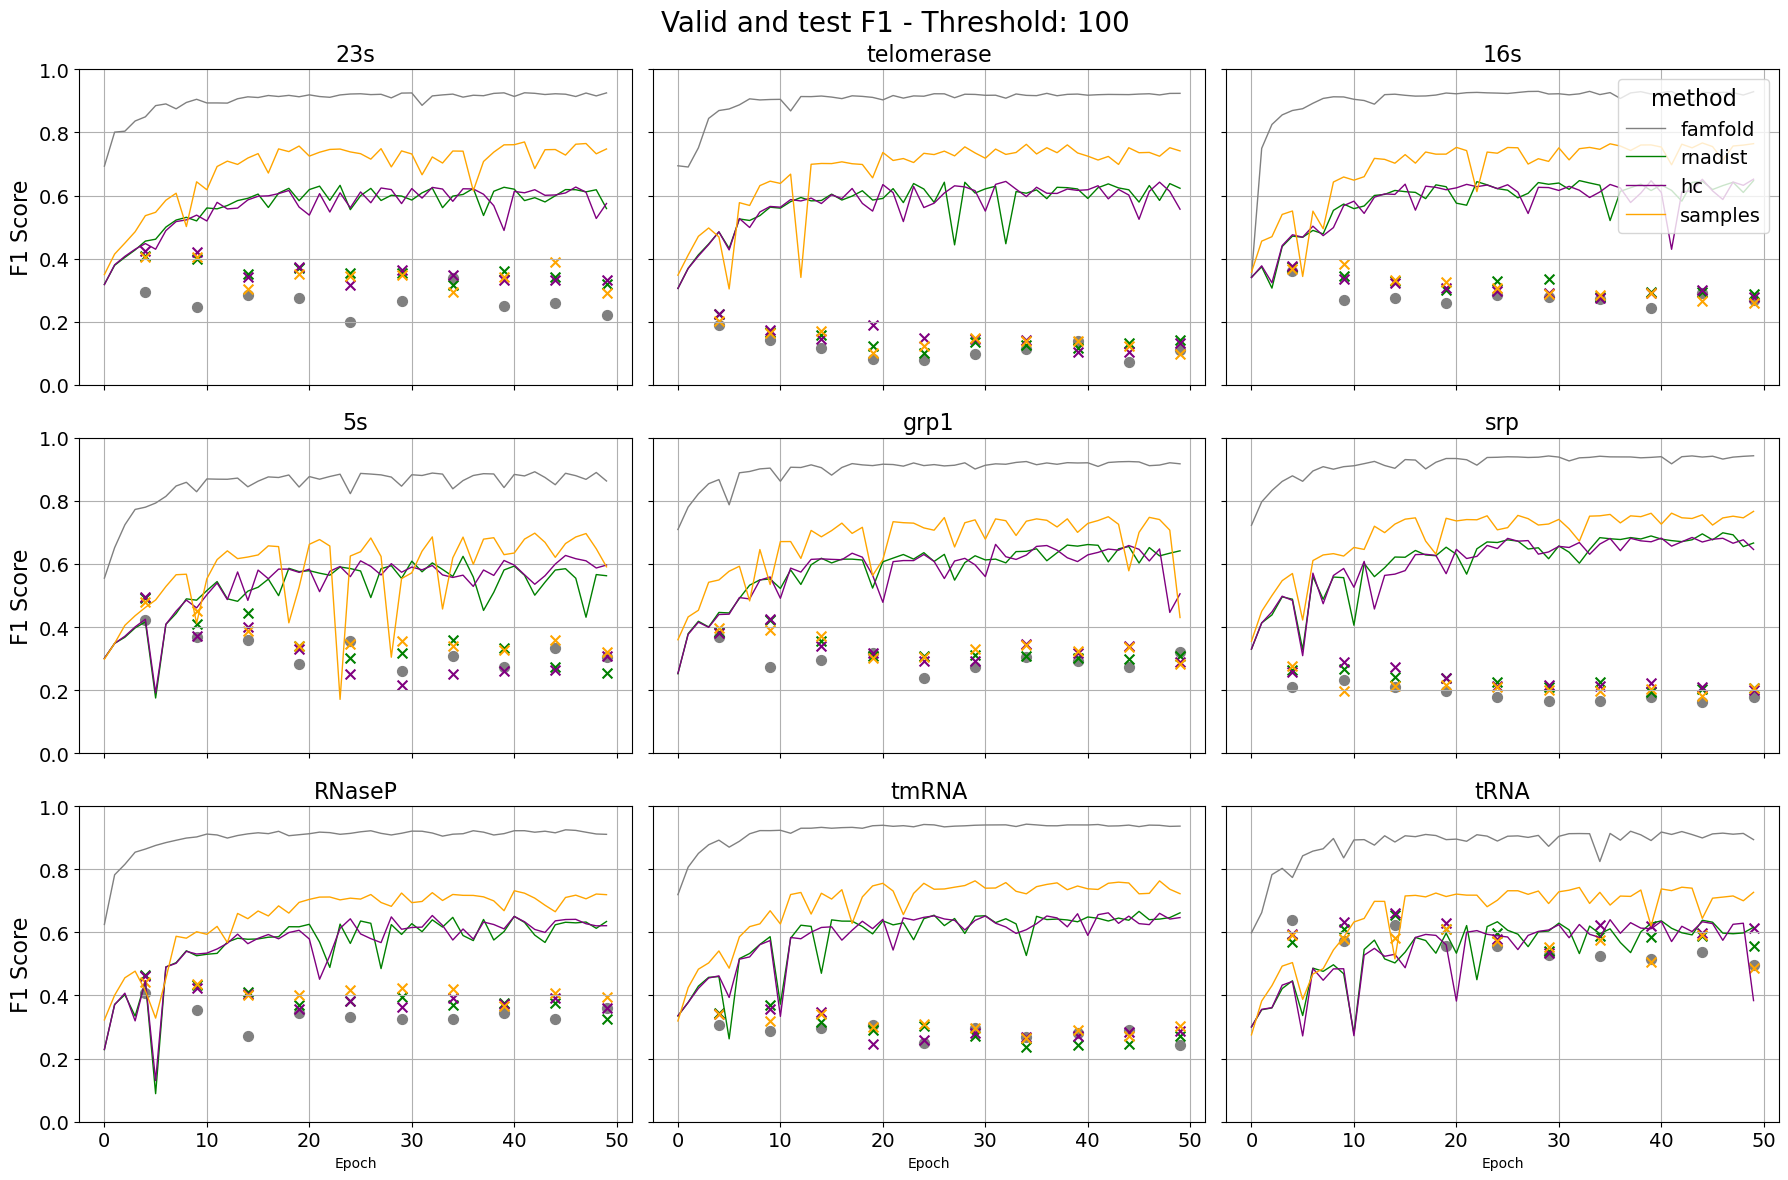

In [154]:
dataset_names = ["famfold","rnadist100", "hc100", "samples100",]
df_list = [dfs_all[k] for k in dataset_names]

plot_valid_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams, 
    save=True
)
